In [58]:
import os
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

os.chdir("/Users/Yannick/Documents/PhD/text_mining/geothermal")


# -----------------------------
# Config
# -----------------------------
SENT_GPKG = "output/text/sentences_with_absa_and_geo_v2.gpkg"
SENT_LAYER_POINTS = "sentences_points"

CBS_GPKG = "data/cbsgebiedsindelingen2025.gpkg"
LAYER_GEMEENTE = "gemeente_gegeneraliseerd"
LAYER_PROVINCIE = "provincie_gegeneraliseerd"

OUT_DIR = "output/figures/sentiment_analysis_geom/geographic_aggregation"
os.makedirs(OUT_DIR, exist_ok=True)


# -----------------------------
# Helpers
# -----------------------------
def pick_col_by_regex(cols, patterns):
    import re
    cols_l = [c.lower() for c in cols]
    for pat in patterns:
        for c, cl in zip(cols, cols_l):
            if re.search(pat, cl):
                return c
    return None

def aggregate_points_to_polygons(
    pts: gpd.GeoDataFrame,
    poly: gpd.GeoDataFrame,
    poly_key_col: str,
    sentiment_col: str = "sentiment_norm",
    predicate: str = "within",  # "within" usually best for points-in-polygons
):
    """
    Returns:
      - poly_out: polygons with n_pos, n_neg, n_neu, n_total
      - counts: table of counts per polygon key
      - audit: dict with basic reconciliation counts
    """
    # Keep only points with geometry
    pts = pts[pts.geometry.notna()].copy()

    # Ensure CRS match
    if pts.crs is None:
        raise ValueError("Points CRS is None. Set pts.crs before calling.")
    if poly.crs is None:
        raise ValueError("Polygon CRS is None.")
    if pts.crs != poly.crs:
        pts = pts.to_crs(poly.crs)

    if sentiment_col not in pts.columns:
        raise ValueError(f"Missing '{sentiment_col}' in points layer.")

    # Normalize sentiment labels (edit here if your values differ)
    s = pts[sentiment_col].astype(str).str.strip().str.lower()
    mapping = {
        "positive": "positive",
        "pos": "positive",
        "neg": "negative",
        "negative": "negative",
        "neutral": "neutral",
        "neu": "neutral",
        "Neutral": "neutral",
        "Positive": "positive",
        "Negative": "negative",
        "Neutral/Uncertain": "neutral",
    }
    pts["_sent"] = s.map(mapping).fillna(s)  # keep original if not in mapping

    # Spatial join: point -> polygon key
    join = gpd.sjoin(
        pts[[sentiment_col, "_sent", "geometry"]],
        poly[[poly_key_col, "geometry"]].copy(),
        how="left",
        predicate=predicate,
    )

    # Audit counts
    n_points = len(pts)
    n_joined = join[poly_key_col].notna().sum()
    n_unassigned = n_points - n_joined

    # Aggregate counts per polygon
    # (pivot_table gives you columns per sentiment class)
    counts = (
        join.dropna(subset=[poly_key_col])
            .pivot_table(
                index=poly_key_col,
                columns="_sent",
                values=sentiment_col,
                aggfunc="size",
                fill_value=0,
            )
            .reset_index()
    )

    # Ensure the three columns exist (even if 0 everywhere)
    for col in ["neutral", "positive", "negative"]:
        if col not in counts.columns:
            counts[col] = 0

    counts = counts.rename(columns={
        "neutral": "n_neu",
        "positive": "n_pos",
        "negative": "n_neg",
    })
    counts["n_total"] = counts["n_neu"] + counts["n_pos"] + counts["n_neg"]

    audit = {
        "n_points_input": int(n_points),
        "n_points_assigned_to_polygon": int(n_joined),
        "n_points_unassigned": int(n_unassigned),
    }

    # Merge back to polygons
    poly_out = poly.copy()
    poly_out = poly_out.merge(counts, on=poly_key_col, how="left")
    for c in ["n_neu", "n_pos", "n_neg", "n_total"]:
        if c in poly_out.columns:
            poly_out[c] = poly_out[c].fillna(0).astype(int)

    return poly_out, counts, audit

# -----------------------------
# Load data
# -----------------------------
pts = gpd.read_file(SENT_GPKG, layer=SENT_LAYER_POINTS)
muni = gpd.read_file(CBS_GPKG, layer=LAYER_GEMEENTE)
prov = gpd.read_file(CBS_GPKG, layer=LAYER_PROVINCIE)

# Detect polygon key columns (prefer statcode; fall back to any code-ish column)
muni_key = pick_col_by_regex(muni.columns, [r"statcode", r"gm_.*code", r"gemeente.*code", r"\bcode\b"])
prov_key = pick_col_by_regex(prov.columns, [r"statcode", r"pv_.*code", r"provincie.*code", r"\bcode\b"])
if muni_key is None or prov_key is None:
    raise ValueError("Could not detect municipality/province code column in CBS layers.")

# Ensure points CRS is set (your points likely already have one)
if pts.crs is None:
    raise ValueError("Points layer has no CRS; set it before reprojecting/joining.")

# -----------------------------
# Filter out country-level centroid points
# -----------------------------
# Get rid of points that were geocoded only to country level
if "llm_granularity" in pts.columns:
    pts = pts[
        pts["llm_granularity"].astype(str).str.strip().str.lower() != "country"
    ].copy()
else:
    print("WARNING: 'llm_granularity' column not found; cannot filter country points.")


# -----------------------------
# Province aggregation
# -----------------------------
prov_out, prov_counts, prov_audit = aggregate_points_to_polygons(
    pts=pts, poly=prov, poly_key_col=prov_key, sentiment_col="sentiment_norm"
)
print("Province audit:", prov_audit)

prov_counts.to_csv(os.path.join(OUT_DIR, "provincie_counts.csv"), index=False)
prov_out.to_file(os.path.join(OUT_DIR, "provincie_counts.gpkg"), layer="provincie_counts", driver="GPKG")

# -----------------------------
# Filter out province-level centroid points for municipality aggregation
# -----------------------------
# Get rid of points that were geocoded only to country level
if "llm_granularity" in pts.columns:
    pts_muni = pts[
        pts["llm_granularity"].astype(str).str.strip().str.lower() != "province"
    ].copy()
else:
    print("WARNING: 'llm_granularity' column not found; cannot filter country points.")


# -----------------------------
# Municipality aggregation
# -----------------------------
muni_out, muni_counts, muni_audit = aggregate_points_to_polygons(
    pts=pts_muni, poly=muni, poly_key_col=muni_key, sentiment_col="sentiment_norm"
)
print("Municipality audit:", muni_audit)

muni_counts.to_csv(os.path.join(OUT_DIR, "gemeente_counts.csv"), index=False)
muni_out.to_file(os.path.join(OUT_DIR, "gemeente_counts.gpkg"), layer="gemeente_counts", driver="GPKG")


print("Saved outputs to:", OUT_DIR)


# -----------------------------
# Add province NAME to points
# -----------------------------

# Detect province name column (CBS usually has something like 'statnaam' or 'provincienaam')
prov_name_col = pick_col_by_regex(
    prov.columns,
    [r"statnaam", r"provincie.*naam", r"\bnaam\b", r"name"]
)

if prov_name_col is None:
    raise ValueError("Could not detect province name column in province layer.")

# Ensure CRS match
if pts.crs != prov.crs:
    prov_for_join = prov.to_crs(pts.crs)
else:
    prov_for_join = prov

# Spatial join: add province name to each point
pts_with_prov = gpd.sjoin(
    pts,
    prov_for_join[[prov_name_col, "geometry"]],
    how="left",
    predicate="within"
).rename(columns={prov_name_col: "province_name"})

# (Optional) drop join index column added by geopandas
pts_with_prov = pts_with_prov.drop(columns=["index_right"], errors="ignore")

print("Added province_name to points dataframe")

# -----------------------------
# Add Municipality NAME to points
# -----------------------------

# Detect municipality name column (CBS usually has something like 'statnaam' or 'gemeentenaam')
muni_name_col = pick_col_by_regex(
    muni.columns,
    [r"statnaam", r"gemeente.*naam", r"\bnaam\b", r"name"]
)

if muni_name_col is None:
    raise ValueError("Could not detect municipality name column in municipality layer.")

# Ensure CRS match
if pts.crs != muni.crs:
    muni_for_join = muni.to_crs(pts.crs)
else:
    muni_for_join = muni

# Spatial join: add municipality name to each point
pts_with_muni = gpd.sjoin(
    pts_with_prov,
    muni_for_join[[muni_name_col, "geometry"]],
    how="left",
    predicate="within"
).rename(columns={muni_name_col: "municipality_name"})

# (Optional) drop join index column added by geopandas
pts_with_muni = pts_with_muni.drop(columns=["index_right"], errors="ignore")

print("Added municipality_name to points dataframe")

# Check duplicates
dups = pts_with_muni.columns[pts_with_muni.columns.duplicated()]
print("Duplicated columns:", list(dups))

# Remove duplicate columns (keep first occurrence)
pts_with_muni = pts_with_muni.loc[:, ~pts_with_muni.columns.duplicated()]

# save back to GPKG (optional)
pts_with_muni.to_file("output/text/final_df.gpkg", index=False, driver="GPKG")

Province audit: {'n_points_input': 12200, 'n_points_assigned_to_polygon': 11978, 'n_points_unassigned': 222}
Municipality audit: {'n_points_input': 11056, 'n_points_assigned_to_polygon': 10834, 'n_points_unassigned': 222}
Saved outputs to: output/figures/sentiment_analysis_geom/geographic_aggregation
Added province_name to points dataframe
Added municipality_name to points dataframe
Duplicated columns: ['province_name', 'municipality_name']


In [43]:
import os
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd


# Reuse OUT_DIR and plot_choropleth from your previous block
# Assumes you already created: muni_out, prov_out (polygons with n_pos, n_neg, n_neu, n_total)

# Load data and directory if needed
CHLORO_DIR = "output/figures/sentiment_analysis_geom/chloro_plots"
IN_DIR = "output/figures/sentiment_analysis_geom/geographic_aggregation"
muni_out = gpd.read_file(os.path.join(IN_DIR, "gemeente_counts.gpkg"), layer="gemeente_counts")
prov_out = gpd.read_file(os.path.join(IN_DIR, "provincie_counts.gpkg"), layer="provincie_counts")

os.makedirs(CHLORO_DIR, exist_ok=True)


def add_percentage_columns(poly_gdf):
    poly = poly_gdf.copy()

    # Make sure counts exist + are numeric
    for c in ["n_pos", "n_neg", "n_neu", "n_total"]:
        if c not in poly.columns:
            raise ValueError(f"Missing column '{c}' in polygon layer.")
        poly[c] = poly[c].fillna(0).astype(float)

    # Avoid divide-by-zero
    denom = poly["n_total"].replace({0: np.nan})

    poly["pct_pos"] = 100.0 * (poly["n_pos"] / denom)
    poly["pct_neg"] = 100.0 * (poly["n_neg"] / denom)
    poly["pct_neu"] = 100.0 * (poly["n_neu"] / denom)

    # If n_total == 0 -> keep NaN so it shows as "No data" in plots
    return poly

# -----------------------------
# Add percentages
# -----------------------------
muni_pct = add_percentage_columns(muni_out)
prov_pct = add_percentage_columns(prov_out)

# Save layers (optional but handy)
muni_pct.to_file(os.path.join(IN_DIR, "gemeente_percentages.gpkg"), layer="gemeente_percentages", driver="GPKG")
prov_pct.to_file(os.path.join(IN_DIR, "provincie_percentages.gpkg"), layer="provincie_percentages", driver="GPKG")

# -----------------------------
# Plotting function
# -----------------------------

def plot_choropleth(poly_map: gpd.GeoDataFrame, value_col: str, title: str, out_path: str):
    fig, ax = plt.subplots(figsize=(9, 11), dpi=200)
    poly_map.plot(
        column=value_col,
        ax=ax,
        legend=True,
        cmap="viridis",
        missing_kwds={"color": "lightgrey", "edgecolor": "white", "hatch": "///", "label": "No data"},
        linewidth=0.2,
        edgecolor="white",
    )
    ax.set_title(title)
    ax.axis("off")
    plt.tight_layout()
    plt.savefig(out_path, bbox_inches="tight")
    plt.close(fig)

# -----------------------------
# Plot municipality percentages
# -----------------------------
plot_choropleth(
    muni_pct, "pct_pos",
    "Gemeenten — % positive sentiment (sentence-level)",
    os.path.join(CHLORO_DIR, "gemeenten_pct_pos.png"),
)
plot_choropleth(
    muni_pct, "pct_neg",
    "Gemeenten — % negative sentiment (sentence-level)",
    os.path.join(CHLORO_DIR, "gemeenten_pct_neg.png"),
)
plot_choropleth(
    muni_pct, "pct_neu",
    "Gemeenten — % neutral sentiment (sentence-level)",
    os.path.join(CHLORO_DIR, "gemeenten_pct_neu.png"),
)

# -----------------------------
# Plot province percentages
# -----------------------------
plot_choropleth(
    prov_pct, "pct_pos",
    "Provincies — % positive sentiment (sentence-level)",
    os.path.join(CHLORO_DIR, "provincies_pct_pos.png"),
)
plot_choropleth(
    prov_pct, "pct_neg",
    "Provincies — % negative sentiment (sentence-level)",
    os.path.join(CHLORO_DIR, "provincies_pct_neg.png"),
)
plot_choropleth(
    prov_pct, "pct_neu",
    "Provincies — % neutral sentiment (sentence-level)",
    os.path.join(CHLORO_DIR, "provincies_pct_neu.png"),
)

# Optional: quick sanity check tables
print(
    "Municipalities (sum counts):",
    int(muni_pct["n_pos"].sum()),
    int(muni_pct["n_neg"].sum()),
    int(muni_pct["n_neu"].sum()),
    int(muni_pct["n_total"].sum()),
)
print(
    "Provinces (sum counts):",
    int(prov_pct["n_pos"].sum()),
    int(prov_pct["n_neg"].sum()),
    int(prov_pct["n_neu"].sum()),
    int(prov_pct["n_total"].sum()),
)

print("Saved percentage figures to:", CHLORO_DIR)


Municipalities (sum counts): 2450 3969 3144 9563
Provinces (sum counts): 2683 4480 3416 10579
Saved percentage figures to: output/figures/sentiment_analysis_geom/chloro_plots


In [44]:
import pandas as pd
import geopandas as gpd
import numpy as np
import re

# -----------------------------
# Config
# -----------------------------
SENTIMENT_COL = "sentiment_norm"
DOC_COL = "body"
OUT_DIR = "output/figures/sentiment_analysis_geom/tables"
os.makedirs(OUT_DIR, exist_ok=True)
OUT_TABLE = os.path.join(OUT_DIR, "provincie_sentiment_table_with_country.csv")

# -----------------------------
# Load data
# -----------------------------

SENT_GPKG = "output/text/sentences_with_absa_and_geo_v2.gpkg"
SENT_LAYER_POINTS = "sentences_points"
pts = gpd.read_file(SENT_GPKG, layer=SENT_LAYER_POINTS)


# -----------------------------
# Helpers
# -----------------------------
def normalize_sentiment(series: pd.Series) -> pd.Series:
    sent_map = {
        "positive": "positive", "pos": "positive",
        "negative": "negative", "neg": "negative",
        "neutral": "neutral",  "neu": "neutral",
    }
    return (
        series.astype(str)
              .str.strip()
              .str.lower()
              .map(sent_map)
    )

def pick_col_by_regex(cols, patterns):
    cols_l = [c.lower() for c in cols]
    for pat in patterns:
        for c, cl in zip(cols, cols_l):
            if re.search(pat, cl):
                return c
    return None

def make_summary_row(df: pd.DataFrame, label_value: str, key_col: str, name_col: str = "province_name") -> pd.DataFrame:
    # df must already have _sent normalized and be filtered to desired rows
    n_pos = int((df["_sent"] == "positive").sum())
    n_neg = int((df["_sent"] == "negative").sum())
    n_neu = int((df["_sent"] == "neutral").sum())
    n_sent = n_pos + n_neg + n_neu
    n_docs = int(df[DOC_COL].nunique())

    denom = n_sent if n_sent > 0 else np.nan
    row = {
        key_col: "COUNTRY",
        name_col: label_value,
        "n_sentences": n_sent,
        "n_documents": n_docs,
        "n_pos": n_pos,
        "n_neg": n_neg,
        "n_neu": n_neu,
        "pct_pos": 100 * n_pos / denom,
        "pct_neg": 100 * n_neg / denom,
        "pct_neu": 100 * n_neu / denom,
        "sentences_per_doc": (n_sent / n_docs) if n_docs > 0 else np.nan,
        "polarity_balance": (100 * n_pos / denom) - (100 * n_neg / denom),
    }
    return pd.DataFrame([row])

# -----------------------------
# Base points table (COMPLETE dataset for country row)
# -----------------------------
pts_all = pts.copy()

if SENTIMENT_COL not in pts_all.columns:
    raise ValueError(f"Missing column '{SENTIMENT_COL}' in points layer")
if DOC_COL not in pts_all.columns:
    raise ValueError(f"Missing column '{DOC_COL}' in points layer")

pts_all["_sent"] = normalize_sentiment(pts_all[SENTIMENT_COL])
pts_all = pts_all[pts_all["_sent"].isin(["positive", "negative", "neutral"])].copy()

# Country overall row uses COMPLETE dataset (including country-level entries)
# (geometry not needed here)
prov_key = pick_col_by_regex(
    prov.columns,
    [r"statcode", r"pv_.*code", r"provincie.*code", r"\bcode\b"]
)
prov_name = pick_col_by_regex(
    prov.columns,
    [r"statnaam", r"provincie.*naam", r"\bnaam\b"]
)

if prov_key is None:
    raise ValueError("Could not detect province code column")

country_row = make_summary_row(
    df=pts_all[[DOC_COL, "_sent"]].copy(),
    label_value="Nederland (overall)",
    key_col=prov_key,
    name_col="province_name" if prov_name is not None else "province_name",
)

# -----------------------------
# Province-level aggregation (FILTER OUT country centroid points)
# -----------------------------
pts_prov = pts_all.copy()

if "llm_granularity" in pts_prov.columns:
    pts_prov = pts_prov[
        pts_prov["llm_granularity"].astype(str).str.strip().str.lower() != "country"
    ].copy()
else:
    print("WARNING: 'llm_granularity' column not found; cannot filter country points.")

# Ensure CRS match for spatial join
if pts_prov.crs is None or prov.crs is None:
    raise ValueError("Both points and provinces must have CRS set.")
if pts_prov.crs != prov.crs:
    pts_prov = pts_prov.to_crs(prov.crs)

join = gpd.sjoin(
    pts_prov[[DOC_COL, "_sent", "geometry"]],
    prov[[prov_key, "geometry"]],
    how="left",
    predicate="within",
)
join = join[join[prov_key].notna()].copy()

# Counts per province
counts = (
    join.pivot_table(
        index=prov_key,
        columns="_sent",
        values=DOC_COL,
        aggfunc="size",
        fill_value=0,
    )
    .reset_index()
)

for c in ["positive", "negative", "neutral"]:
    if c not in counts.columns:
        counts[c] = 0

counts = counts.rename(columns={
    "positive": "n_pos",
    "negative": "n_neg",
    "neutral": "n_neu",
})
counts["n_sentences"] = counts["n_pos"] + counts["n_neg"] + counts["n_neu"]

denom = counts["n_sentences"].replace({0: np.nan})
counts["pct_pos"] = 100 * counts["n_pos"] / denom
counts["pct_neg"] = 100 * counts["n_neg"] / denom
counts["pct_neu"] = 100 * counts["n_neu"] / denom

# Documents per province = unique body values
doc_counts = (
    join.groupby(prov_key)[DOC_COL]
        .nunique()
        .reset_index(name="n_documents")
)
counts = counts.merge(doc_counts, on=prov_key, how="left")

# Extra stats
counts["sentences_per_doc"] = counts["n_sentences"] / counts["n_documents"]
counts["polarity_balance"] = counts["pct_pos"] - counts["pct_neg"]

# Add province name
if prov_name is not None:
    counts = counts.merge(
        prov[[prov_key, prov_name]],
        on=prov_key,
        how="left",
    ).rename(columns={prov_name: "province_name"})
else:
    counts["province_name"] = None

# -----------------------------
# Combine: country + provinces
# -----------------------------
final_tbl = pd.concat([country_row, counts], ignore_index=True)

# Reorder columns nicely
ordered_cols = [
    prov_key, "province_name",
    "n_sentences", "n_documents",
    "n_pos", "n_neg", "n_neu",
    "pct_pos", "pct_neg", "pct_neu",
    "sentences_per_doc",
    "polarity_balance",
]
final_tbl = final_tbl[ordered_cols]

# Sort with country first, then by total sentences
final_tbl["_sort_key"] = (final_tbl[prov_key] != "COUNTRY").astype(int)
final_tbl = final_tbl.sort_values(["_sort_key", "n_sentences"], ascending=[True, False]).drop(columns="_sort_key")

# Save + preview
final_tbl.to_csv(OUT_TABLE, index=False)
print("Saved province sentiment table (with country row) to:", OUT_TABLE)
print(final_tbl.head(15))


Saved province sentiment table (with country row) to: output/figures/sentiment_analysis_geom/tables/provincie_sentiment_table_with_country.csv
   statcode        province_name  n_sentences  n_documents  n_pos  n_neg  \
0   COUNTRY  Nederland (overall)        14130         1361   3611   6147   
9      PV28         Zuid-Holland         2285          270    702    840   
8      PV27        Noord-Holland         1442          133    413    534   
1      PV20            Groningen         1148          104    229    625   
11     PV30        Noord-Brabant         1052          123    253    417   
2      PV21              Fryslân         1027          101    238    443   
6      PV25           Gelderland          902          107    193    417   
4      PV23           Overijssel          835          101    234    320   
12     PV31              Limburg          804           70    149    429   
7      PV26              Utrecht          715           83    156    316   
3      PV22          

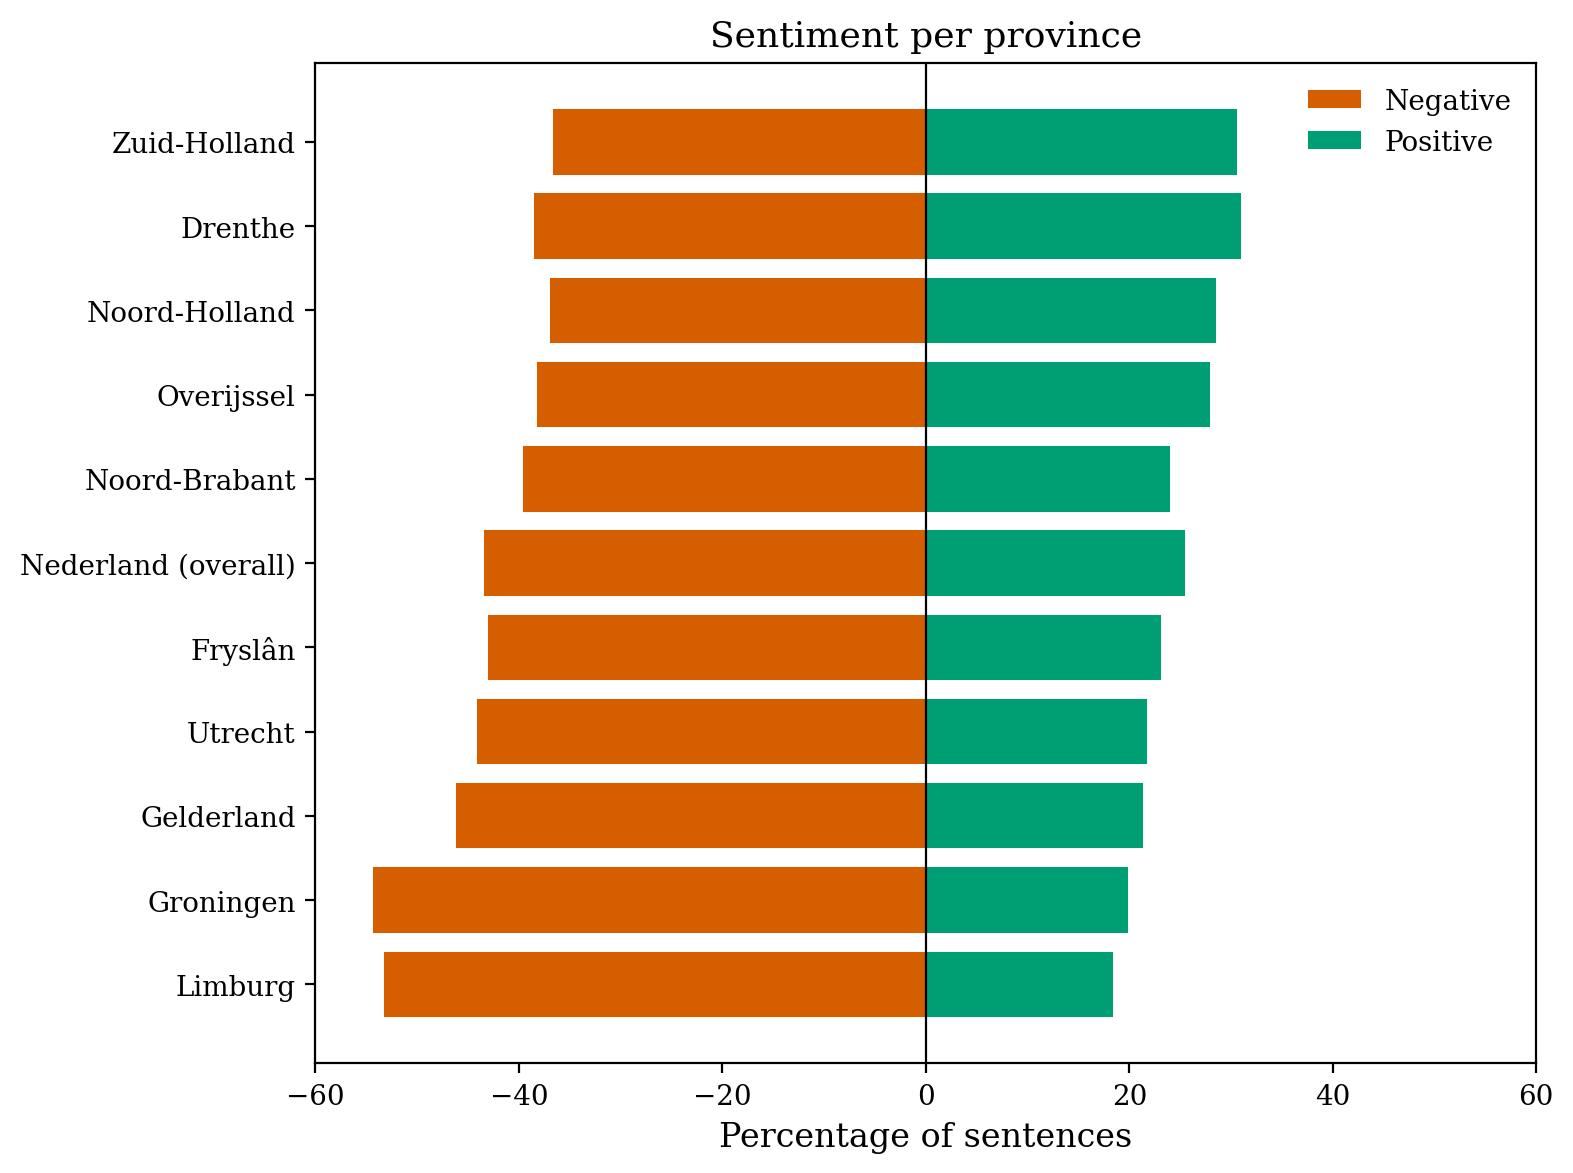

In [77]:
import matplotlib.pyplot as plt
import pandas as pd
import os

# -----------------------------
# Config
# -----------------------------
OTHER_DIR = "output/figures/sentiment_analysis_geom/other_plots"
os.makedirs(OTHER_DIR, exist_ok=True)

df = final_tbl.copy()

# Remove country row for province-only chart
df = df[~df["province_name"].isin(["Zeeland", "Flevoland"])].copy()

# Sort by polarity balance
df = df.sort_values("polarity_balance")

# Same colorblind-friendly palette as before
sentiment_colors = {
    "negative": "#D55E00",
    "neutral":  "#999999",
    "positive": "#009E73",
}

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

fig, ax = plt.subplots(figsize=(8, 6), dpi=200)

# Set xlim for balanced visualization
ax.set_xlim(-60, 60)

# Negative on the left, positive on the right
ax.barh(
    df["province_name"],
    -df["pct_neg"],
    label="Negative",
    color=sentiment_colors["negative"],
    edgecolor="white",
    linewidth=0.7,
)

ax.barh(
    df["province_name"],
    df["pct_pos"],
    label="Positive",
    color=sentiment_colors["positive"],
    edgecolor="white",
    linewidth=0.7,
)

ax.axvline(0, color="black", linewidth=0.8)

ax.set_xlabel("Percentage of sentences")
ax.set_title("Sentiment per province")

# Add full bounding box
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.8)
    spine.set_color("black")

# Remove gridlines
ax.grid(False)

ax.legend(frameon=False)

plt.tight_layout()
plt.savefig(os.path.join(OTHER_DIR, "provincies_sentiment_balance.png"), bbox_inches="tight")
plt.show()

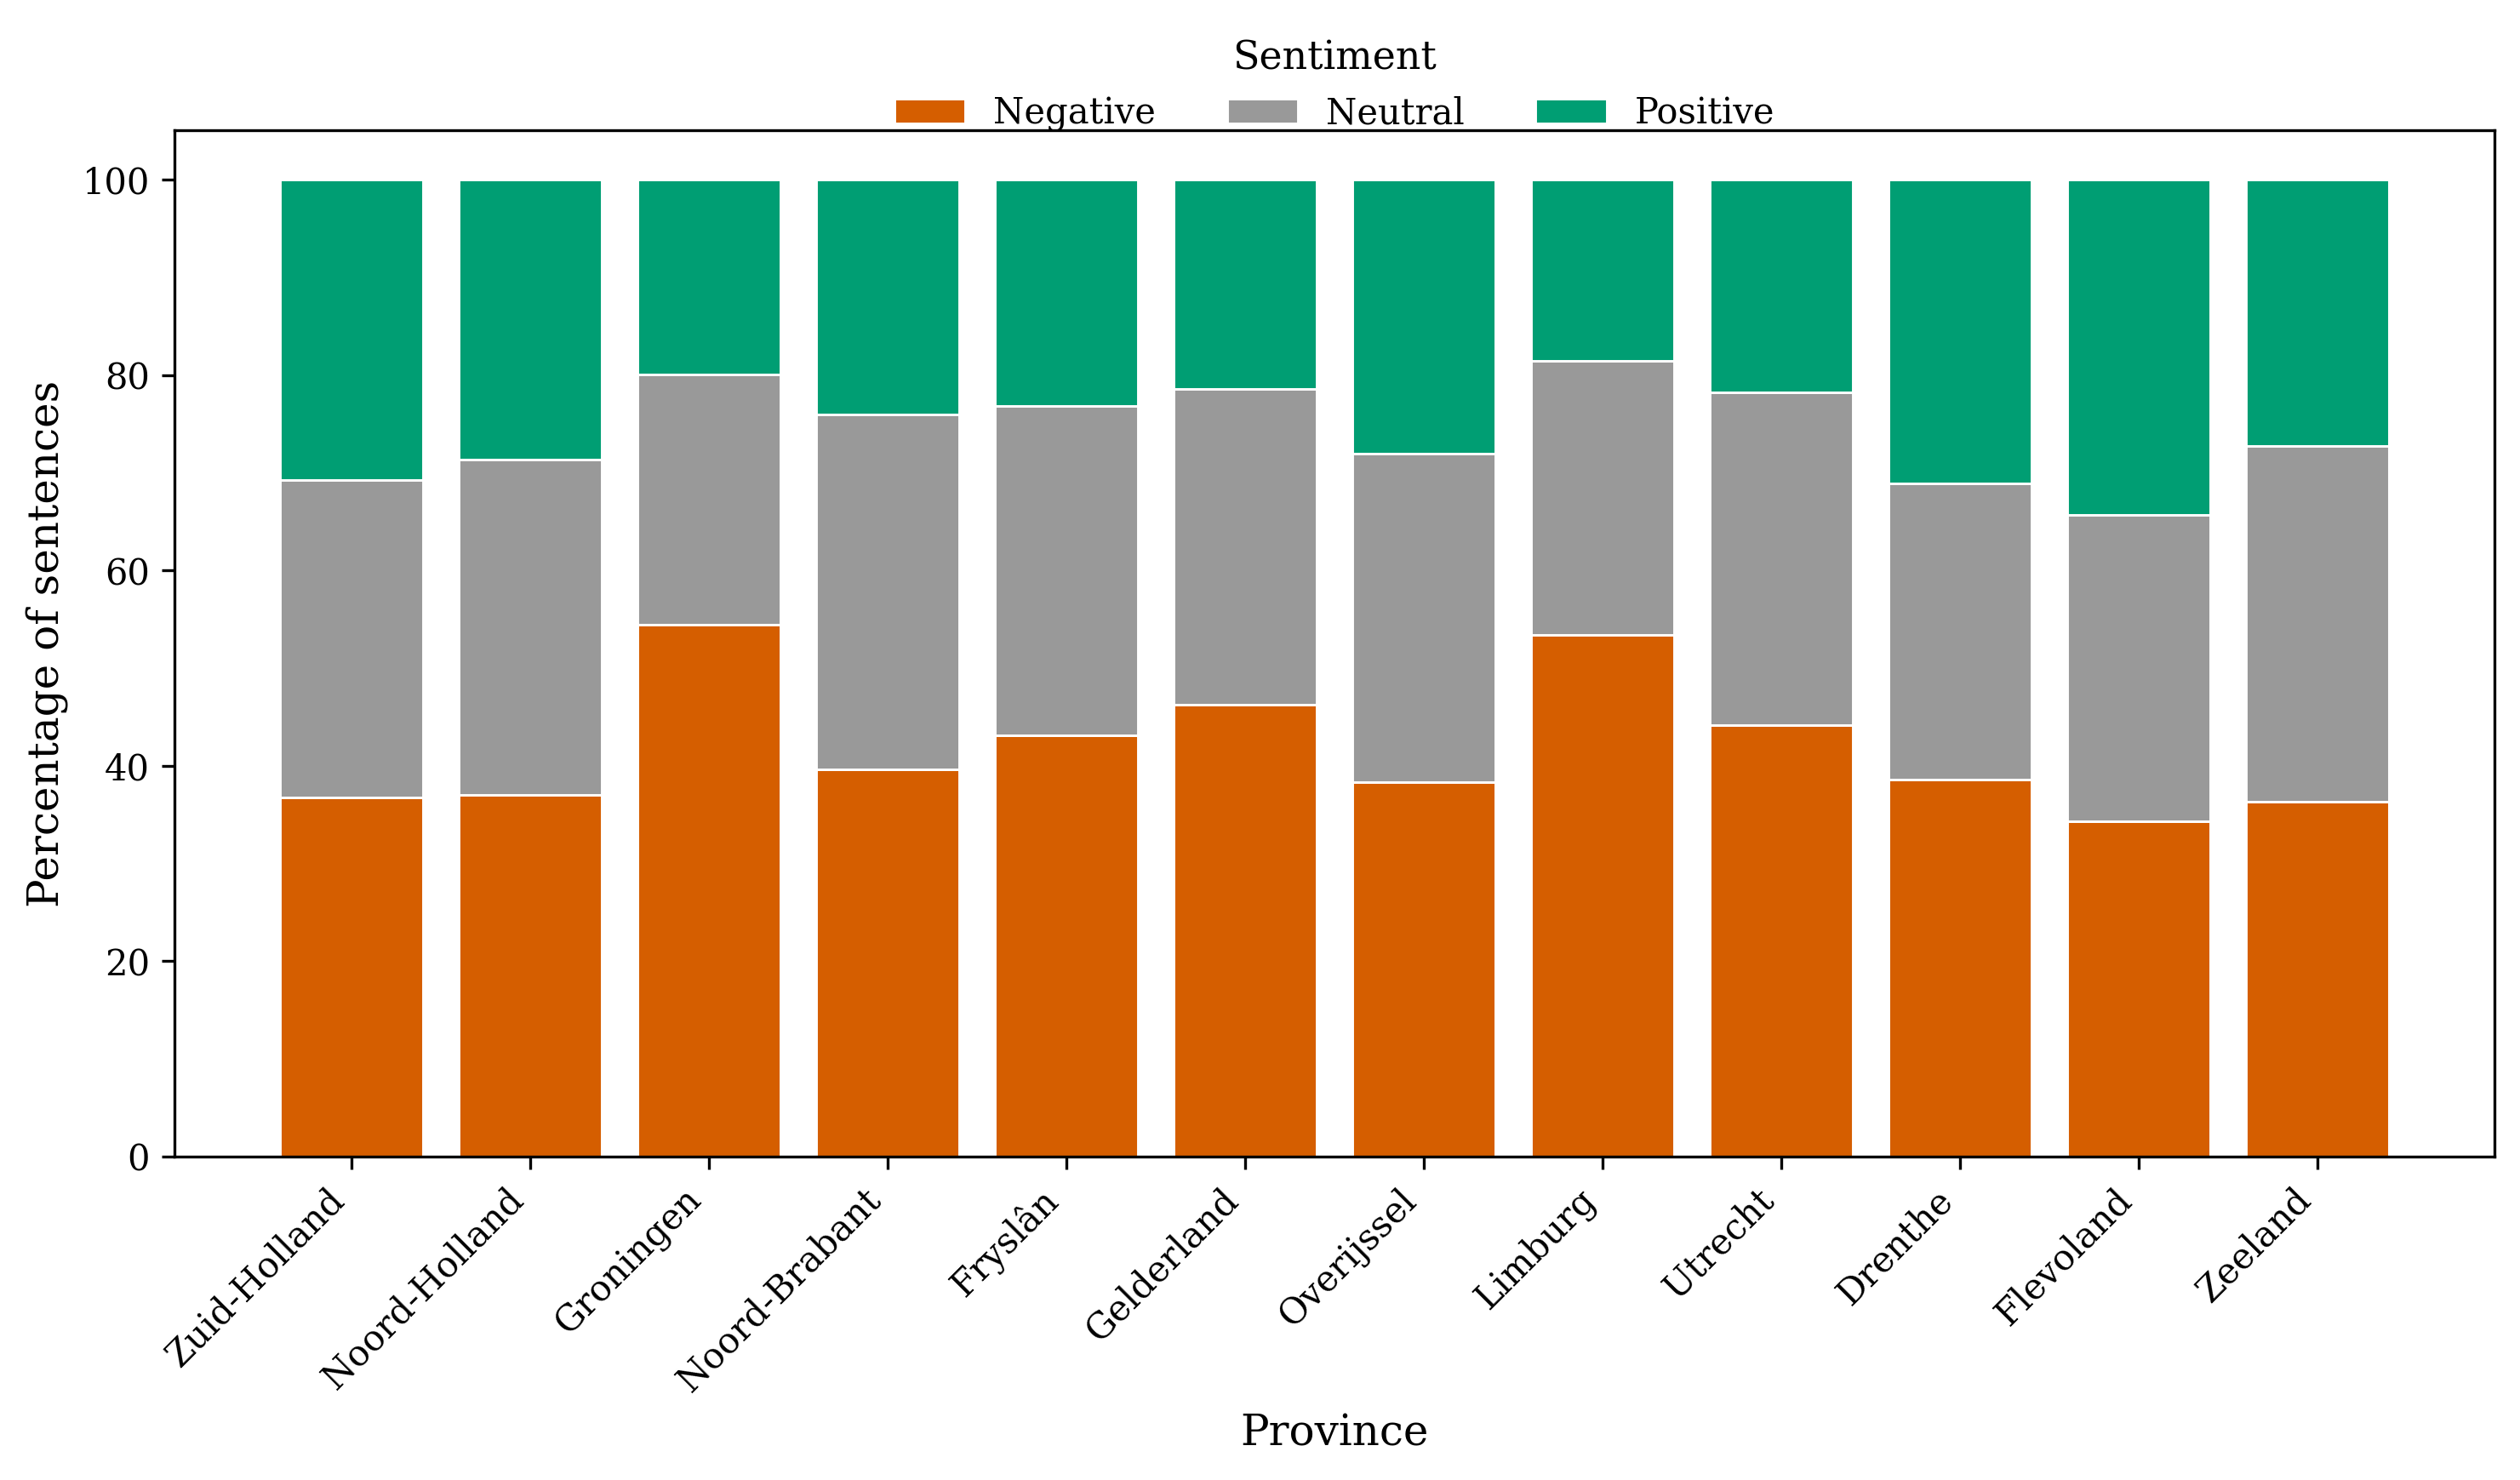

In [78]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Settings
# -----------------------------
category_col = "province_name"

# Set to False if you do NOT want the "Nederland (overall)" / COUNTRY row in the chart
include_country_row = False

# Plot counts or percentages
plot_percentages = True

# Optional: load from CSV instead of using final_tbl already in memory
# df = pd.read_csv("output/figures/sentiment_analysis_geom/tables/provincie_sentiment_table_with_country.csv")
df = final_tbl.copy()

# Colorblind-friendly palette
sentiment_order = ["negative", "neutral", "positive"]
sentiment_colors = {
    "negative": "#D55E00",
    "neutral":  "#999999",
    "positive": "#009E73",
}

# -----------------------------
# Validate input
# -----------------------------
required_cols = [category_col, "n_neg", "n_neu", "n_pos"]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# -----------------------------
# Prepare plot data
# -----------------------------
plot_df = df.copy()

# Drop rows without category labels
plot_df = plot_df.dropna(subset=[category_col])

# Optionally remove country row
if not include_country_row:
    if "COUNTRY" in plot_df.columns:
        plot_df = plot_df[plot_df["COUNTRY"] != "COUNTRY"]
    if "province_name" in plot_df.columns:
        plot_df = plot_df[
            ~plot_df["province_name"].astype(str).str.contains("overall", case=False, na=False)
        ]
    if plot_df.shape[0] > 0 and category_col in plot_df.columns:
        plot_df = plot_df[
            plot_df[category_col].astype(str).str.strip().str.lower() != "nederland (overall)"
        ]

# Keep only needed columns
plot_df = plot_df[[category_col, "n_neg", "n_neu", "n_pos"]].copy()

# Combine duplicates if any
plot_df = (
    plot_df.groupby(category_col, as_index=True)[["n_neg", "n_neu", "n_pos"]]
           .sum()
)

# Sort by total number of sentences
plot_df["total"] = plot_df["n_neg"] + plot_df["n_neu"] + plot_df["n_pos"]
plot_df = plot_df.sort_values("total", ascending=False)

# Convert to percentages if requested
if plot_percentages:
    denom = plot_df["total"].replace({0: pd.NA})
    plot_data = pd.DataFrame(index=plot_df.index)
    plot_data["negative"] = 100 * plot_df["n_neg"] / denom
    plot_data["neutral"]  = 100 * plot_df["n_neu"] / denom
    plot_data["positive"] = 100 * plot_df["n_pos"] / denom
    y_label = "Percentage of sentences"
else:
    plot_data = pd.DataFrame(index=plot_df.index)
    plot_data["negative"] = plot_df["n_neg"]
    plot_data["neutral"]  = plot_df["n_neu"]
    plot_data["positive"] = plot_df["n_pos"]
    y_label = "Number of sentences"

# -----------------------------
# Plot
# -----------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

bottom = pd.Series(0, index=plot_data.index, dtype=float)

for sentiment in sentiment_order:
    ax.bar(
        plot_data.index,
        plot_data[sentiment],
        bottom=bottom,
        label=sentiment.capitalize(),
        color=sentiment_colors[sentiment],
        edgecolor="white",
        linewidth=0.7,
    )
    bottom += plot_data[sentiment]

# Styling

ax.set_xlabel("Province")
ax.set_ylabel(y_label)

ax.spines["top"].set_visible(True)
ax.spines["right"].set_visible(True)
ax.set_axisbelow(True)

plt.xticks(rotation=45, ha="right")

ax.legend(
    title="Sentiment",
    frameon=False,
    ncol=3,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.12),
)

plt.tight_layout()
plt.show()

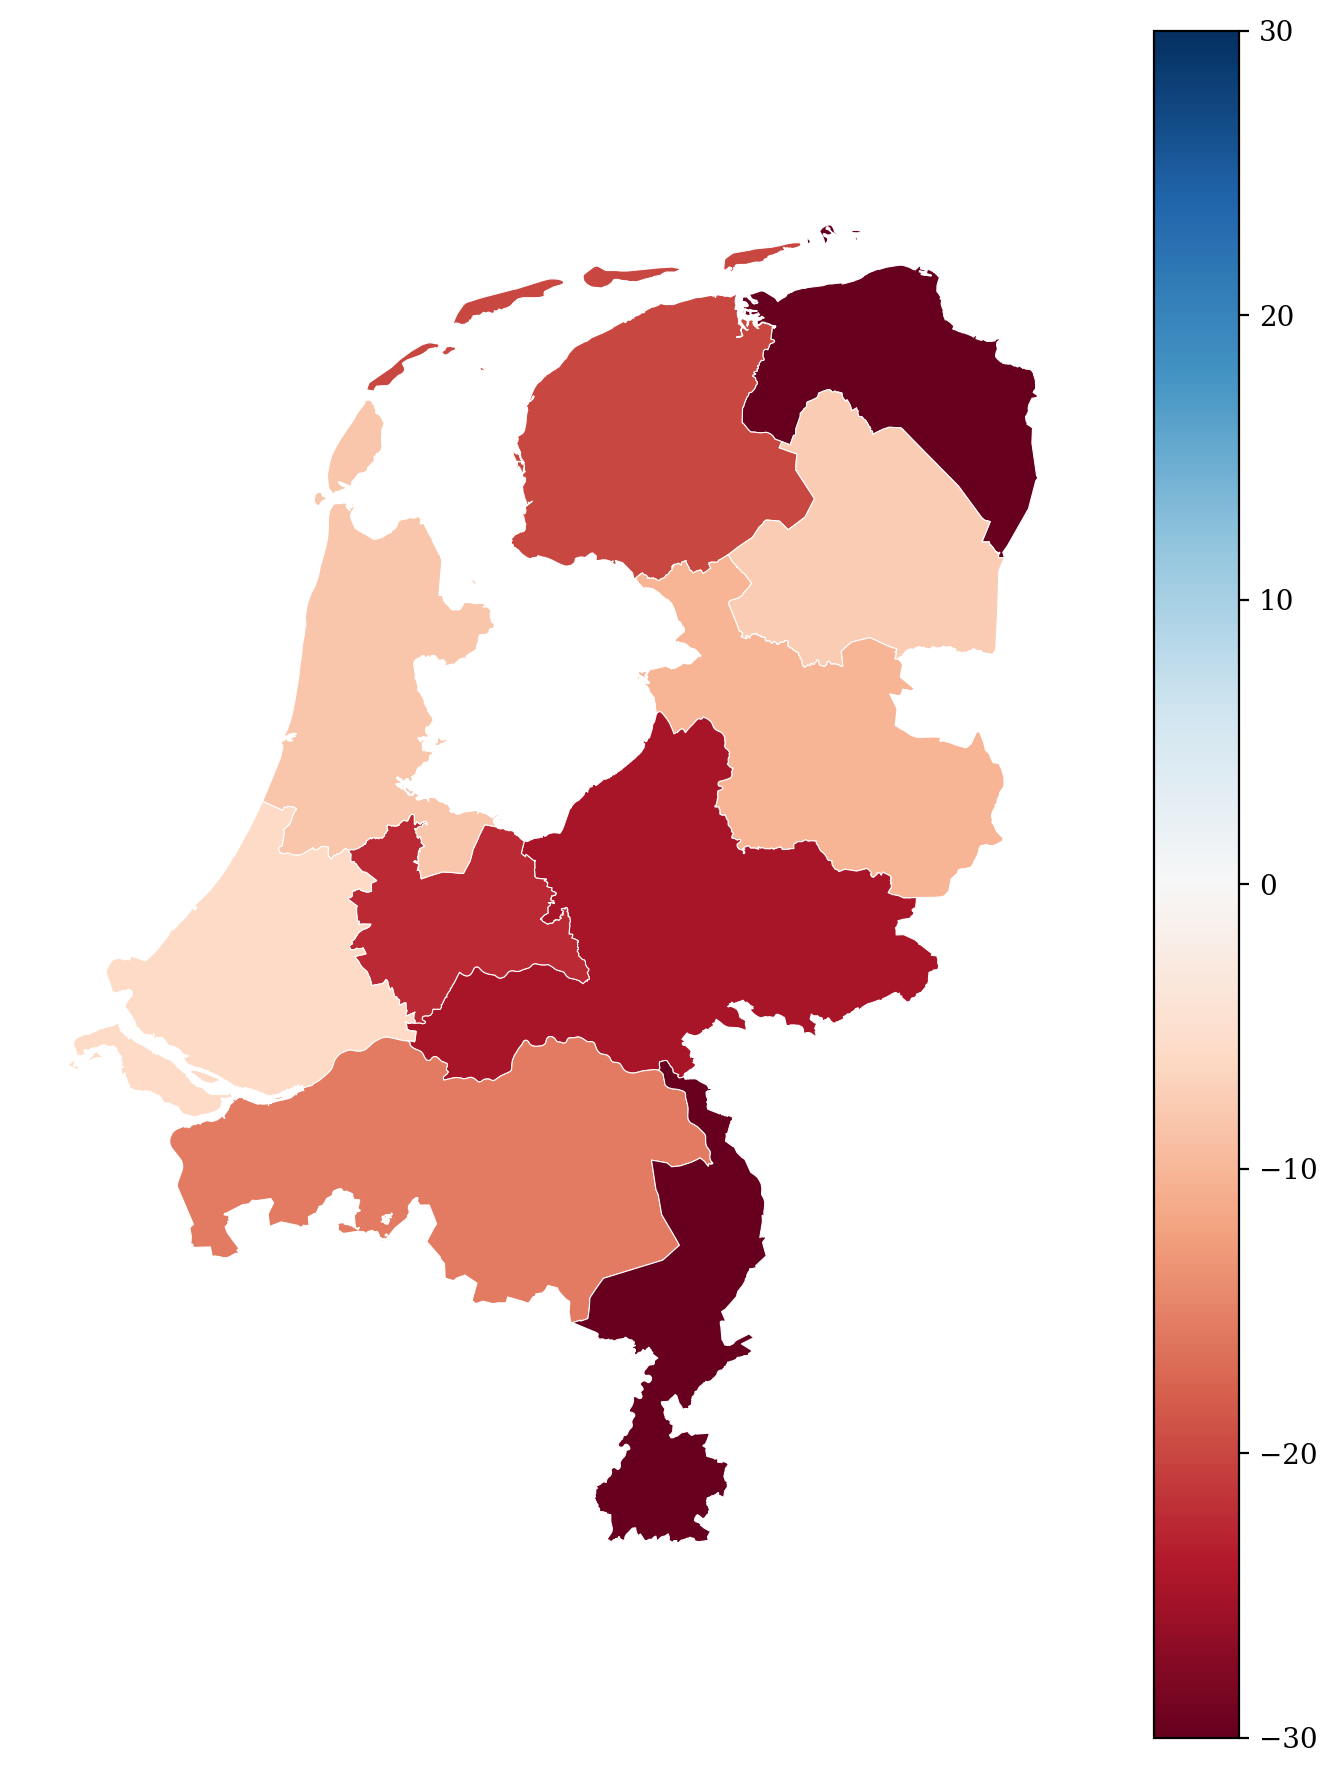

In [51]:
from matplotlib.colors import TwoSlopeNorm

fig, ax = plt.subplots(figsize=(7, 9), dpi=200)

chlor_prov_pct = prov_pct[~prov_pct["statcode"].isin(["PV29", "PV24"])].copy()

chlor_prov_pct["polarity_balance"] = chlor_prov_pct["pct_pos"] - chlor_prov_pct["pct_neg"]
norm = TwoSlopeNorm(vmin=-30, vcenter=0, vmax=30)

chlor_prov_pct.plot(
    column="polarity_balance",
    cmap="RdBu",
    norm=norm,
    linewidth=0.4,
    edgecolor="white",
    legend=True,
    ax=ax,
    missing_kwds={"color": "lightgrey", "label": "No data"},
)

ax.axis("off")

plt.tight_layout()

plt.savefig(os.path.join(CHLORO_DIR, "provincies_sentiment_balance_chloro.png"), bbox_inches="tight")
plt.show()


15953
15433


/var/folders/g8/0gz518ls57g4pghsnqh995yc0000gn/T/ipykernel_8653/2617870856.py:42: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  ts["date"] = pd.to_datetime(ts["date"], errors="coerce")


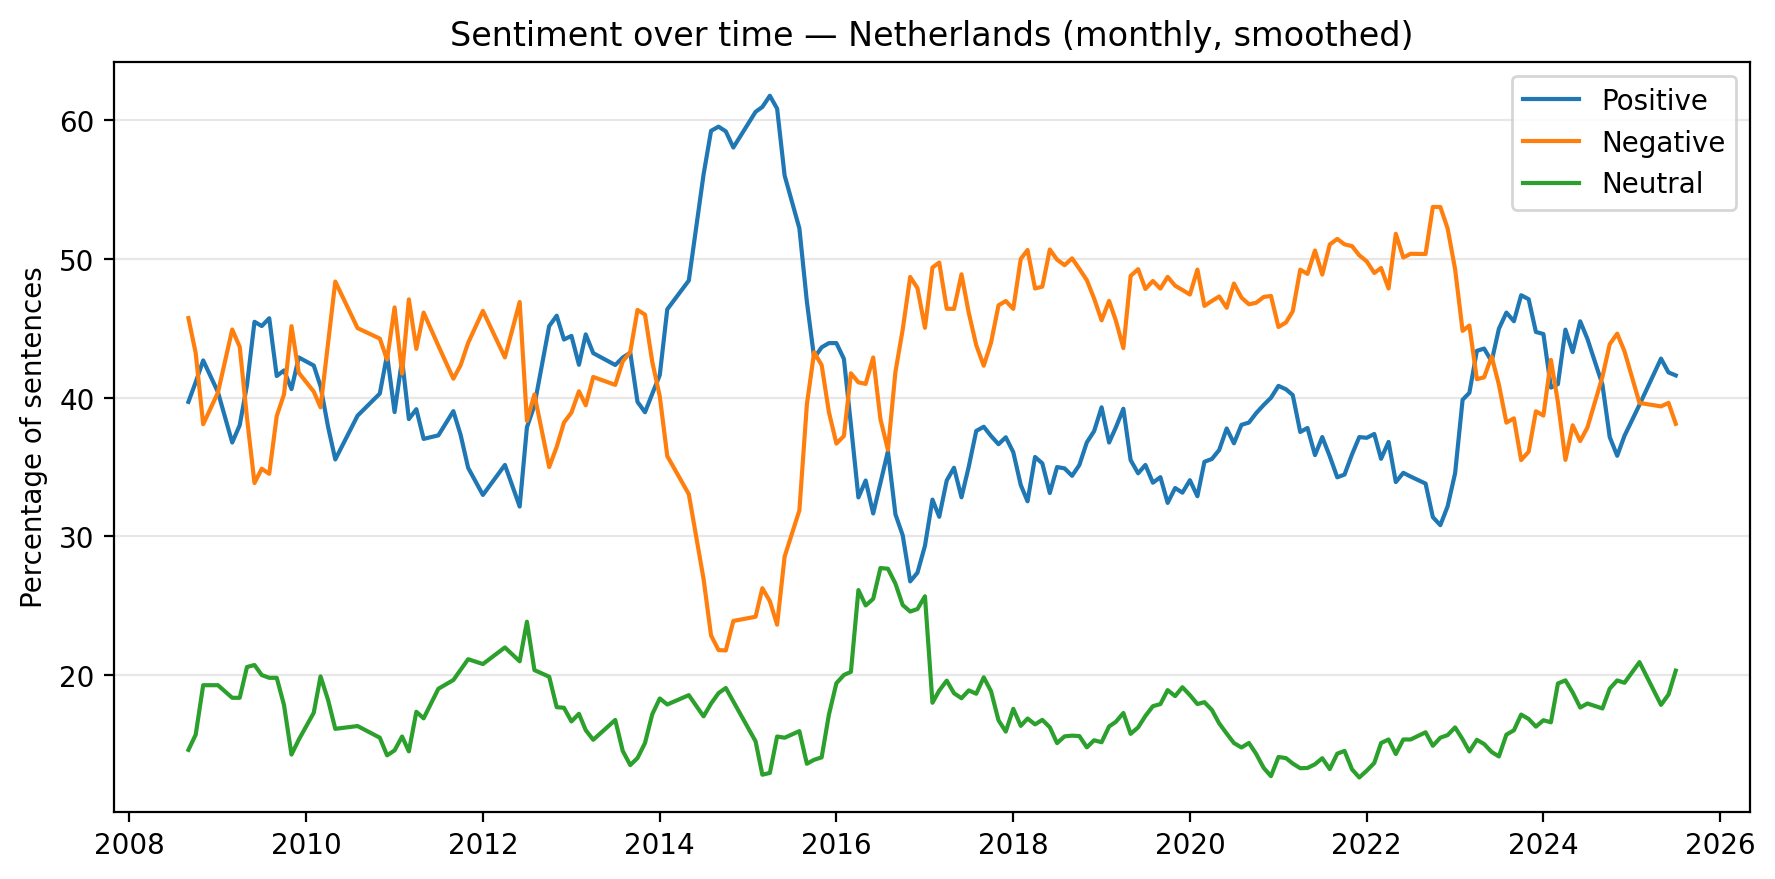

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Load data
# -----------------------------

SENT_GPKG = "output/text/sentences_with_absa_and_geo_v2.gpkg"
SENT_LAYER_POINTS = "sentences_points"
pts = gpd.read_file(SENT_GPKG, layer=SENT_LAYER_POINTS)


# -----------------------------
# Prepare national-level data
# -----------------------------
ts = pts.copy()
print(len(ts))

MONTHS_NL_TO_EN = {
    "januari": "january",
    "februari": "february",
    "maart": "march",
    "april": "april",
    "mei": "may",
    "juni": "june",
    "juli": "july",
    "augustus": "august",
    "september": "september",
    "oktober": "october",
    "november": "november",
    "december": "december",
}

def normalize_dutch_dates(s: pd.Series) -> pd.Series:
    s = s.astype(str).str.lower()
    for nl, en in MONTHS_NL_TO_EN.items():
        s = s.str.replace(nl, en, regex=False)
    return s

ts["date"] = normalize_dutch_dates(ts["date"])
# Parse dates
ts["date"] = pd.to_datetime(ts["date"], errors="coerce")
ts = ts[ts["date"].notna()].copy()
print(len(ts))

# Normalize sentiment
sent_map = {
    "positive": "positive", "pos": "positive",
    "negative": "negative", "neg": "negative",
    "neutral": "neutral",  "neu": "neutral",
}
ts["_sent"] = (
    ts["sentiment_norm"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map(sent_map)
)

ts = ts[ts["_sent"].isin(["positive", "negative", "neutral"])]

# -----------------------------
# Aggregate by month
# -----------------------------
ts["month"] = ts["date"].dt.to_period("M").dt.to_timestamp()

monthly = (
    ts.groupby(["month", "_sent"])
      .size()
      .unstack(fill_value=0)
      .reset_index()
)

monthly["n_total"] = monthly[["positive", "negative", "neutral"]].sum(axis=1)

monthly["pct_pos"] = 100 * monthly["positive"] / monthly["n_total"]
monthly["pct_neg"] = 100 * monthly["negative"] / monthly["n_total"]
monthly["pct_neu"] = 100 * monthly["neutral"] / monthly["n_total"]

# Optional smoothing
window = 10  # months
monthly["pct_pos_smooth"] = monthly["pct_pos"].rolling(window, center=True).mean()
monthly["pct_neg_smooth"] = monthly["pct_neg"].rolling(window, center=True).mean()
monthly["pct_neu_smooth"] = monthly["pct_neu"].rolling(window, center=True).mean()

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(9, 4.5), dpi=200)

ax.plot(monthly["month"], monthly["pct_pos_smooth"], label="Positive")
ax.plot(monthly["month"], monthly["pct_neg_smooth"], label="Negative")
ax.plot(monthly["month"], monthly["pct_neu_smooth"], label="Neutral")


ax.set_ylabel("Percentage of sentences")
ax.set_title("Sentiment over time — Netherlands (monthly, smoothed)")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
plt.savefig(os.path.join(OTHER_DIR, "sentiment_over_time.png"), bbox_inches="tight")

plt.tight_layout()
plt.show()


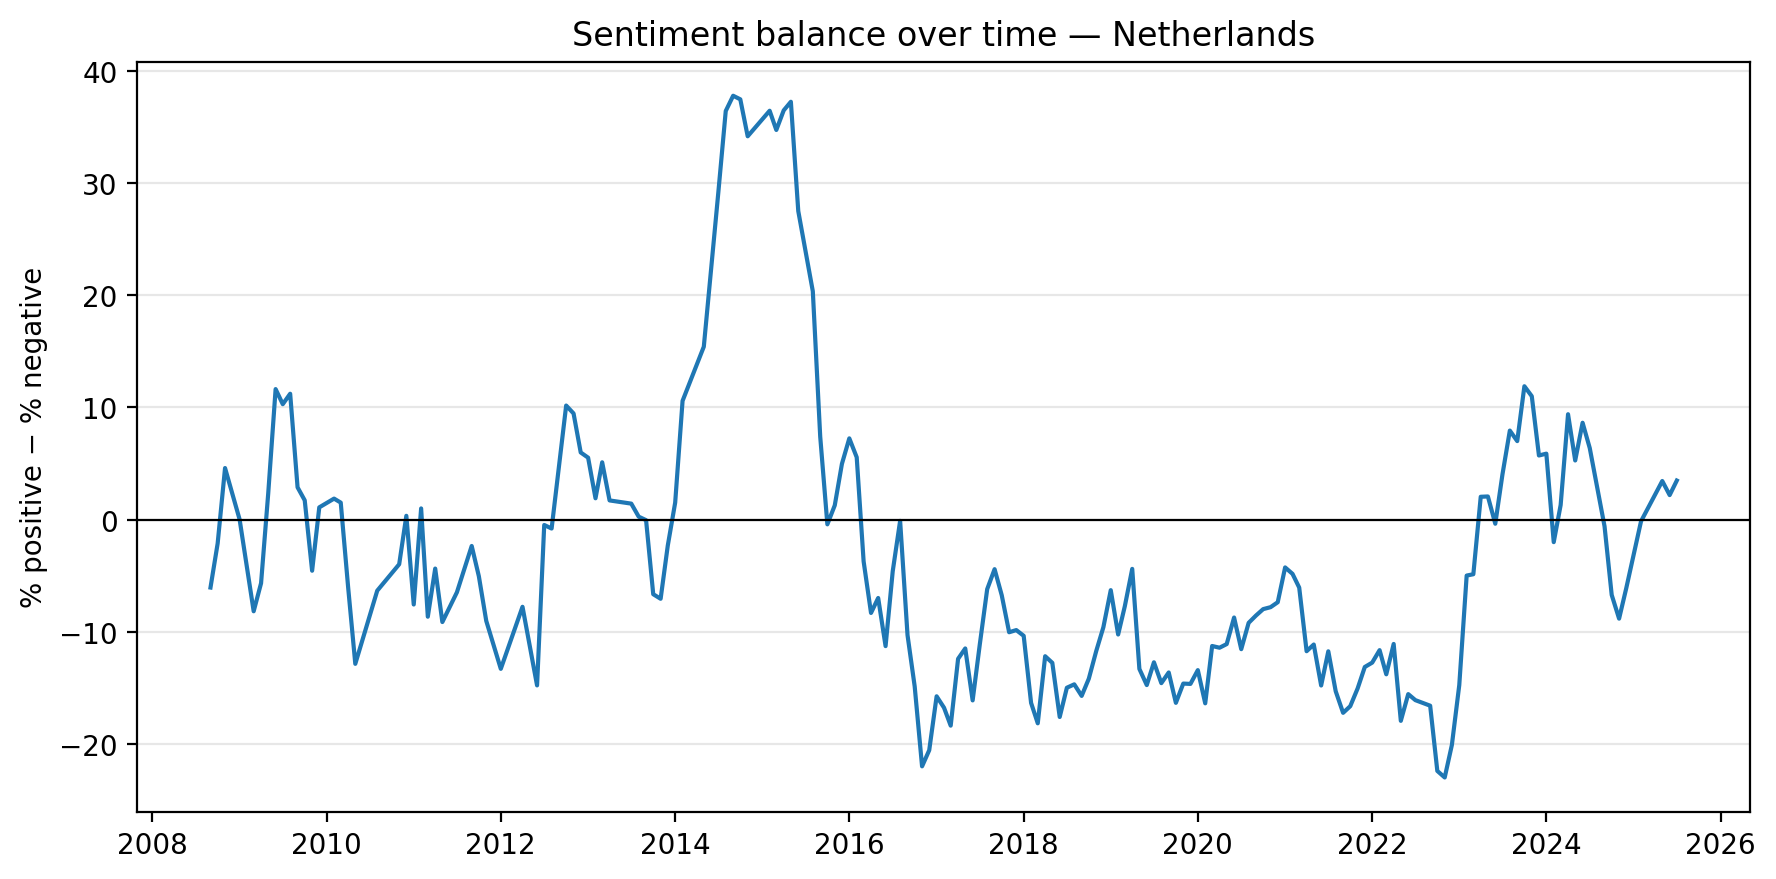

In [9]:
monthly["polarity_balance"] = monthly["pct_pos"] - monthly["pct_neg"]
monthly["polarity_balance_smooth"] = (
    monthly["polarity_balance"]
    .rolling(window, center=True)
    .mean()
)

fig, ax = plt.subplots(figsize=(9, 4.5), dpi=200)

ax.plot(
    monthly["month"],
    monthly["polarity_balance_smooth"],
)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("% positive − % negative")
ax.set_title("Sentiment balance over time — Netherlands")
ax.grid(True, axis="y", alpha=0.3)

plt.savefig(os.path.join(OTHER_DIR, "sentiment_balance_over_time.png"), bbox_inches="tight")
plt.tight_layout()
plt.show()


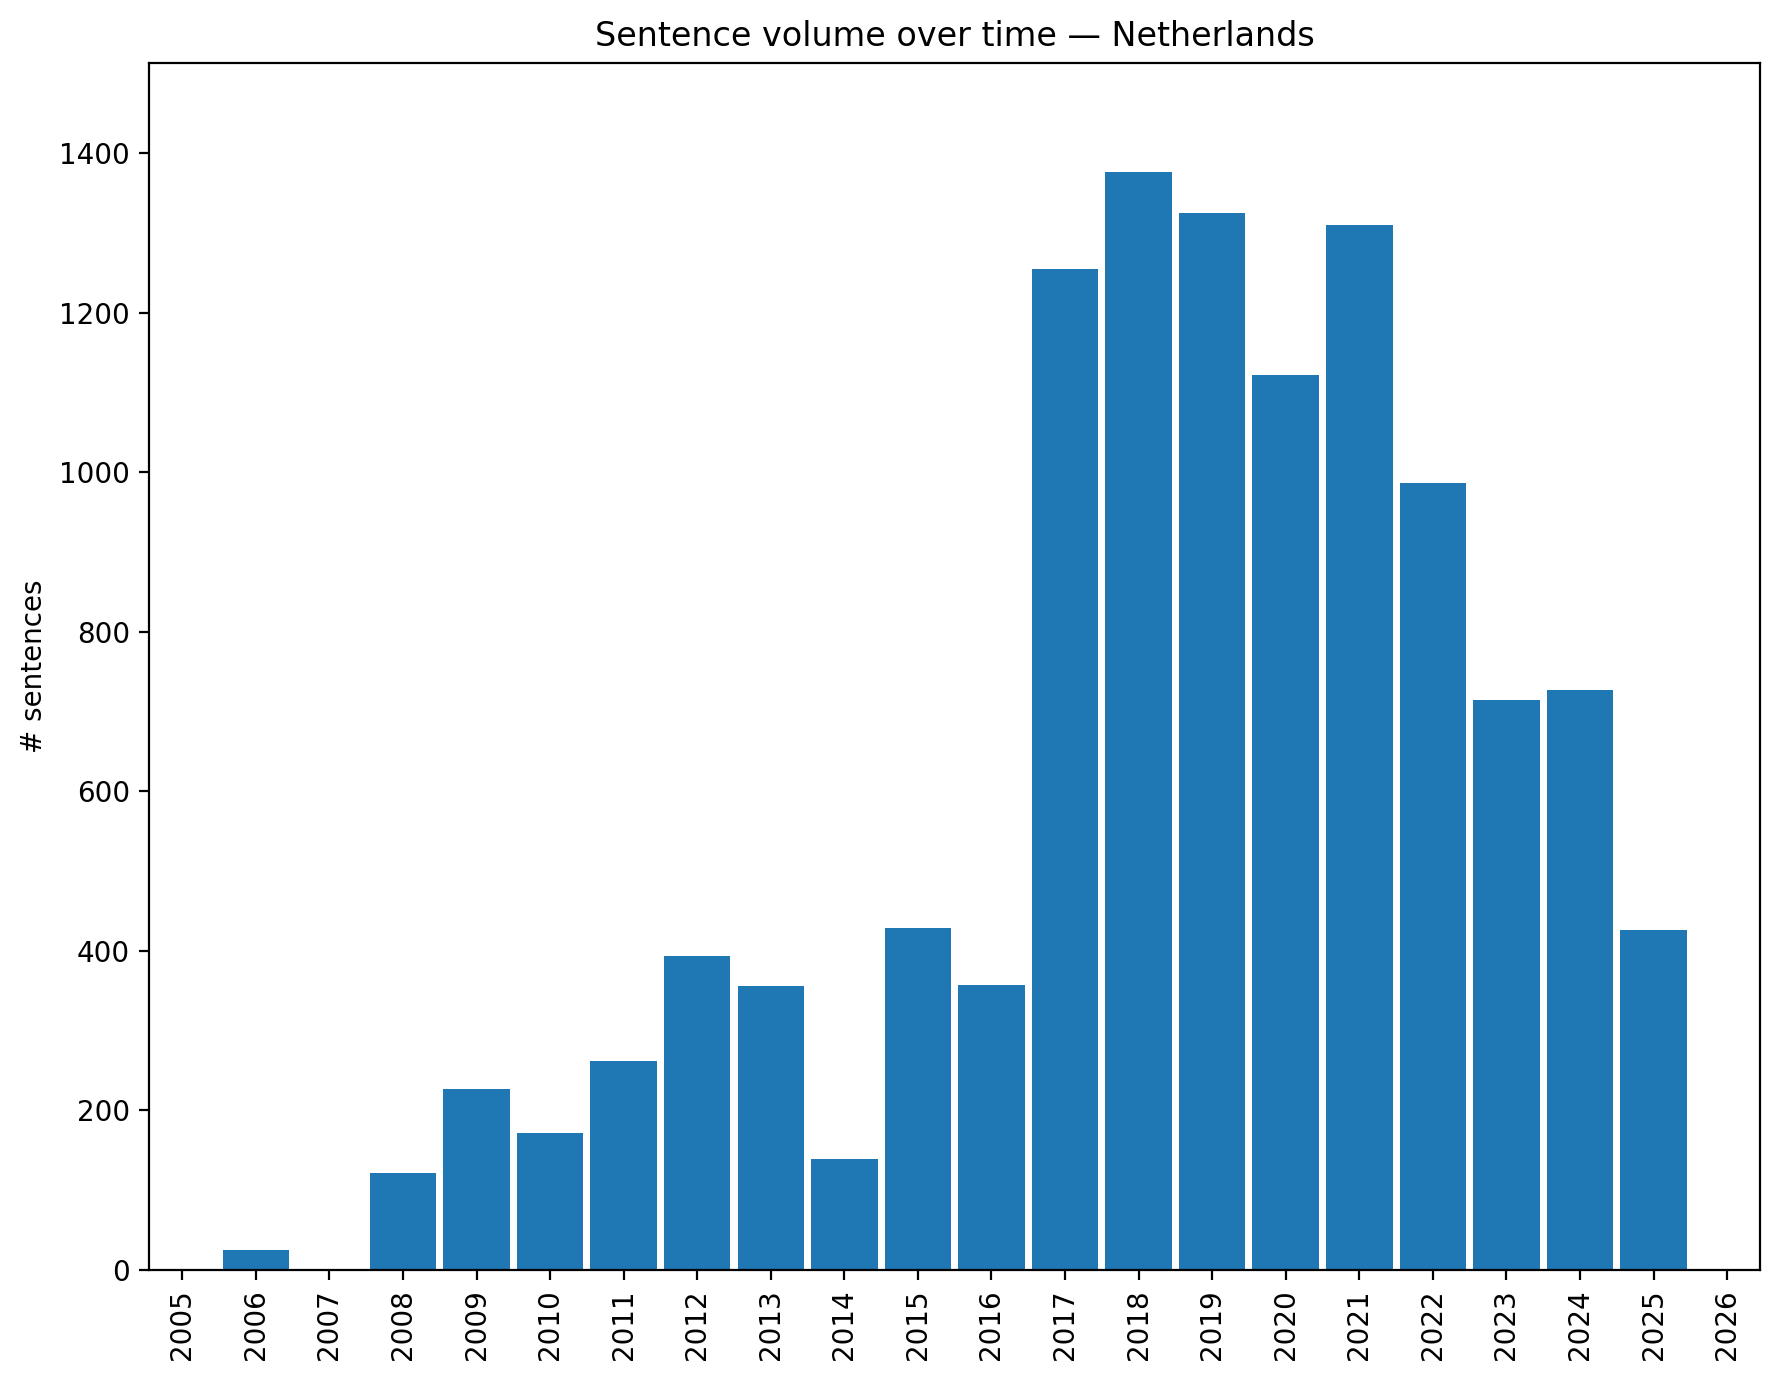

In [10]:
import matplotlib.dates as mdates

yearly = (monthly
          .groupby(pd.Grouper(key="month", freq="YS"))["n_total"]
          .sum()
          .to_frame("n_total"))

fig, ax = plt.subplots(figsize=(9, 7), dpi=200)

ax.bar(yearly.index, yearly["n_total"], width=pd.Timedelta(days=330))

ax.set_ylim(0, yearly["n_total"].max() * 1.1)
ax.set_ylabel("# sentences")
ax.set_title("Sentence volume over time — Netherlands")

# yearly ticks + nice year labels
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(rotation=90)

plt.tight_layout()
plt.savefig(os.path.join(OTHER_DIR, "nl_sentence_volume_over_time.png"), bbox_inches="tight")
plt.show()


Unique aspects: 2442
Aspects kept (min mentions): 59

Most positive aspects:
_sent        aspect  n_total    pct_pos    pct_neg    pct_neu  \
607     energiebron       47  78.723404  14.893617   6.382979   
2326    windenergie       31  70.967742  12.903226  16.129032   
1526        panelen       30  60.000000   6.666667  33.333333   
593         energie      230  62.608696  22.173913  15.217391   
817      geothermie      583  59.519726  25.728988  14.751286   
1647    proefboring       41  51.219512  21.951220  26.829268   
357            bron       33  51.515152  30.303030  18.181818   
1911       subsidie       58  44.827586  24.137931  31.034483   
1266        locatie       65  53.846154  35.384615  10.769231   
2207      warmtenet      158  42.405063  24.050633  33.544304   
1924        systeem       50  52.000000  36.000000  12.000000   
2208   warmtenetten       56  42.857143  28.571429  28.571429   
55       aardwarmte      477  48.846960  36.268344  14.884696   
1038    insta

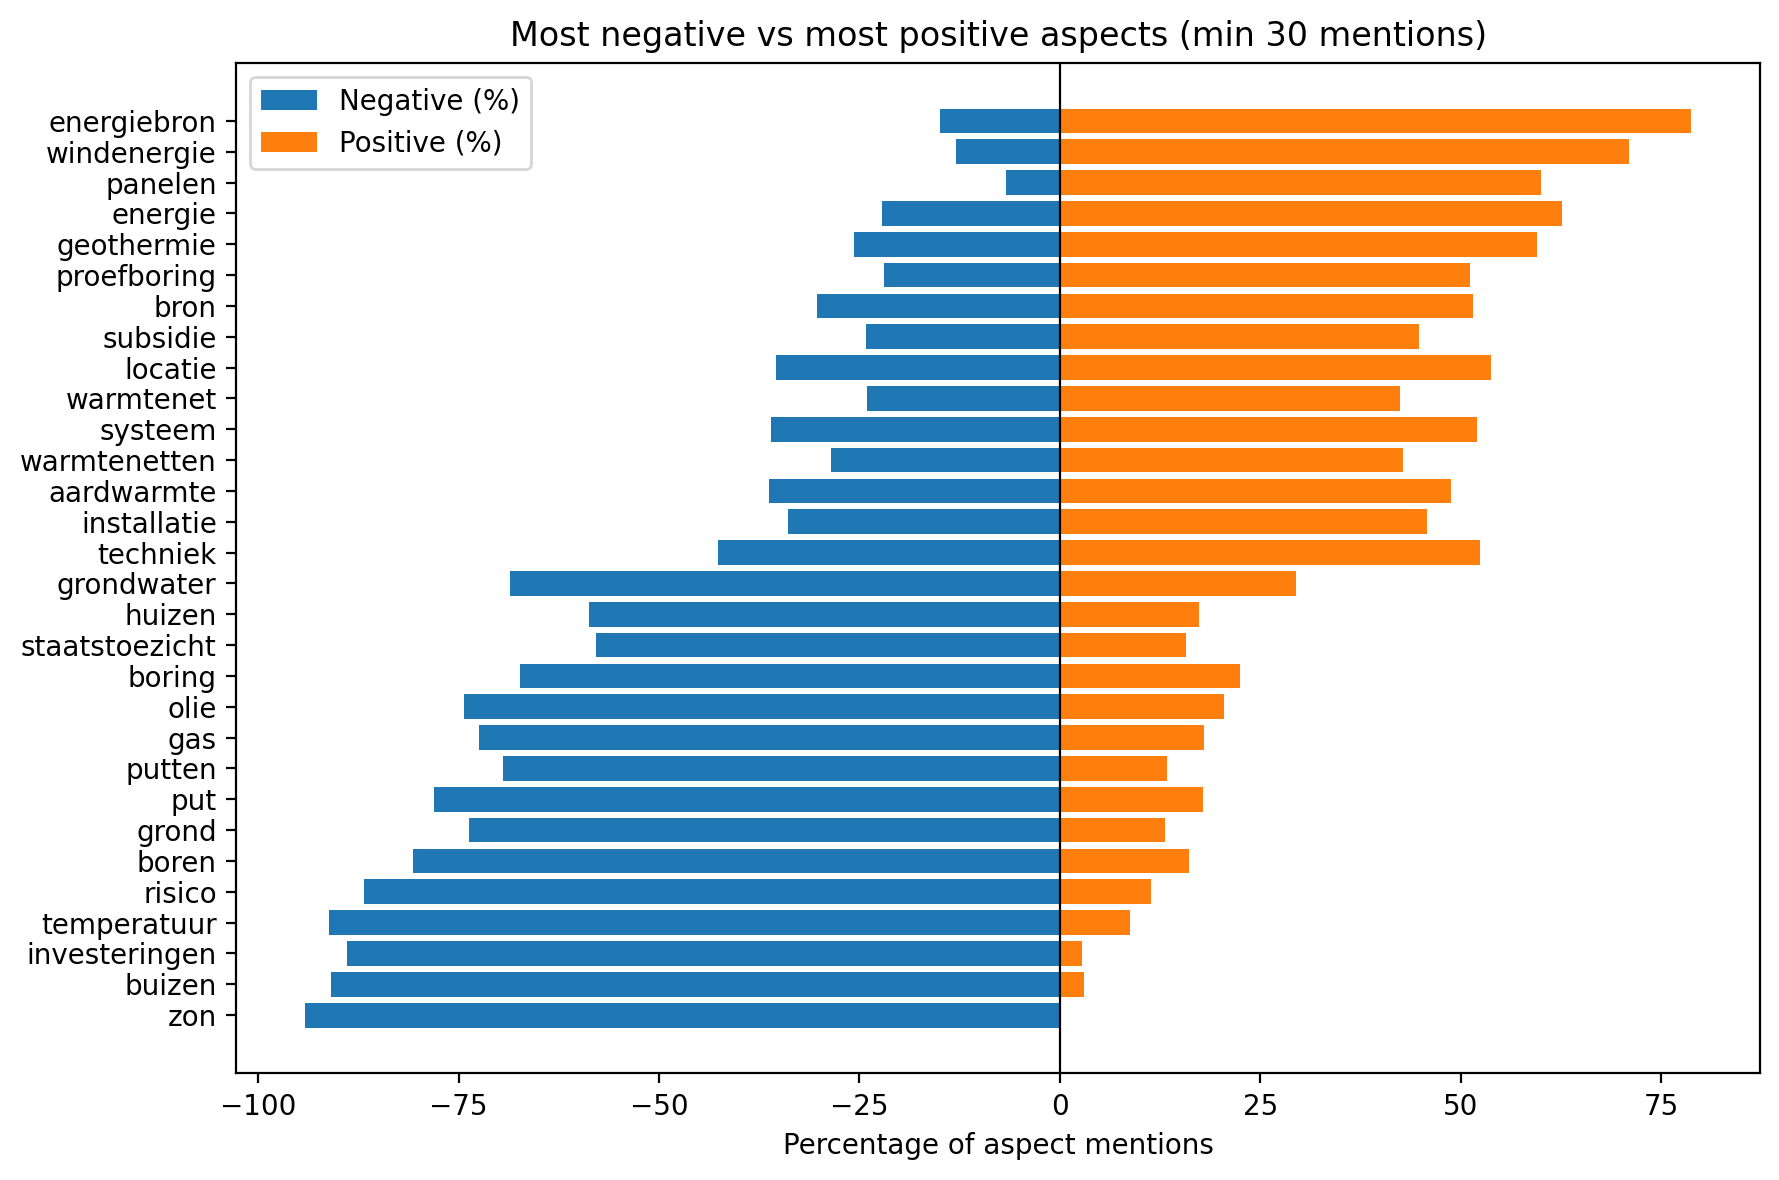

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Base table (already exploded)
# -----------------------------
df = pts.copy()

ASPECTS_DIR = "output/figures/sentiment_analysis_geom/aspect_results"
os.makedirs(ASPECTS_DIR, exist_ok=True)

# Normalize sentiment
sent_map = {
    "positive": "positive", "pos": "positive",
    "negative": "negative", "neg": "negative",
    "neutral": "neutral",  "neu": "neutral",
}
df["_sent"] = (
    df["sentiment_norm"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map(sent_map)
)
df = df[df["_sent"].isin(["positive", "negative", "neutral"])].copy()

# Aspect column (already exploded => one aspect per row)
df = df[(df["aspect"].notna()) & (df["aspect"] != "") & (df["aspect"] != "nan")].copy()
df["aspect"] = df["aspect"].astype(str).str.strip().str.lower()

# -----------------------------
# Aggregate per aspect
# -----------------------------
aspect_counts = (
    df.pivot_table(
        index="aspect",
        columns="_sent",
        values="sentiment_norm",
        aggfunc="size",
        fill_value=0,
    )
    .reset_index()
)

# Ensure columns exist
for c in ["positive", "negative", "neutral"]:
    if c not in aspect_counts.columns:
        aspect_counts[c] = 0

aspect_counts = aspect_counts.rename(columns={
    "positive": "n_pos",
    "negative": "n_neg",
    "neutral": "n_neu",
})
aspect_counts["n_total"] = aspect_counts["n_pos"] + aspect_counts["n_neg"] + aspect_counts["n_neu"]

denom = aspect_counts["n_total"].replace({0: np.nan})
aspect_counts["pct_pos"] = 100 * aspect_counts["n_pos"] / denom
aspect_counts["pct_neg"] = 100 * aspect_counts["n_neg"] / denom
aspect_counts["pct_neu"] = 100 * aspect_counts["n_neu"] / denom

# A single-number score: >0 means more positive than negative
aspect_counts["polarity_balance"] = aspect_counts["pct_pos"] - aspect_counts["pct_neg"]

# -----------------------------
# Filter out rare aspects (important)
# -----------------------------
MIN_MENTIONS = 30  # tweak as needed
acf = aspect_counts[aspect_counts["n_total"] >= MIN_MENTIONS].copy()

print("Unique aspects:", aspect_counts.shape[0])
print("Aspects kept (min mentions):", acf.shape[0])

# -----------------------------
# Top tables
# -----------------------------
top_pos = acf.sort_values("polarity_balance", ascending=False).head(15)
top_neg = acf.sort_values("polarity_balance", ascending=True).head(15)

print("\nMost positive aspects:")
print(top_pos[["aspect","n_total","pct_pos","pct_neg","pct_neu","polarity_balance"]])

print("\nMost negative aspects:")
print(top_neg[["aspect","n_total","pct_pos","pct_neg","pct_neu","polarity_balance"]])

# Save (optional)
top_pos.to_csv(os.path.join(ASPECTS_DIR, "aspects_most_positive.csv"), index=False)
top_neg.to_csv(os.path.join(ASPECTS_DIR, "aspects_most_negative.csv"), index=False)
acf.to_csv(os.path.join(ASPECTS_DIR, "aspects_all_filtered.csv"), index=False)

# -----------------------------
# Best visual: diverging bar chart (top pos & top neg)
# -----------------------------
plot_df = pd.concat([top_neg, top_pos], ignore_index=True)

# Order so negatives on top, positives bottom (or reverse if you prefer)
plot_df["order"] = np.arange(len(plot_df))
plot_df = plot_df.sort_values("polarity_balance")

fig, ax = plt.subplots(figsize=(9, 6), dpi=200)

# negative to the left, positive to the right
ax.barh(plot_df["aspect"], -plot_df["pct_neg"], label="Negative (%)")
ax.barh(plot_df["aspect"],  plot_df["pct_pos"], label="Positive (%)")

ax.axvline(0, linewidth=0.8, color="black")
ax.set_xlabel("Percentage of aspect mentions")
ax.set_title(f"Most negative vs most positive aspects (min {MIN_MENTIONS} mentions)")
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(ASPECTS_DIR, "aspects_diverging_pos_vs_neg.png"))
plt.show()


In [ ]:
import geopandas as gpd
import os

os.chdir("/Users/Yannick/Documents/PhD/text_mining/geothermal")

# Extract the document texts for some locations
locations_of_interest = ["Zuid-Holland", "Limburg"]

LOCATION_DIR = "output/figures/sentiment_analysis_geom/location_sentences"
df = gpd.read_file("output/text/final_df.gpkg")

# Columns you want to keep
cols_to_save = [
    'sentence_text',
    'aspect',
    'sentiment',
    'llm_location',
    'newspaper',
    'date',
    'body',
    'source'
]

os.makedirs(LOCATION_DIR, exist_ok=True)

for loc in locations_of_interest:
    loc_df = df[df["province_name"].str.contains(loc, case=False, na=False)].copy()

    if loc_df.empty:
        print(f"No sentences found for location: {loc}")
        continue

    # Keep only selected columns (only those that actually exist)
    existing_cols = [c for c in cols_to_save if c in loc_df.columns]
    loc_df = loc_df[existing_cols]

    # Keep only unique articles based on 'body'
    if 'body' in loc_df.columns:
        before = len(loc_df)
        loc_df_small = loc_df.drop_duplicates(subset='body')
        after = len(loc_df_small)


    print(f"Found {len(loc_df_small)} documents for location: {loc}")

    out_path = os.path.join(
        LOCATION_DIR,
        f"sentences_with_aspects_{loc.replace(' ', '_')}.csv"
    )

    
    loc_df.to_csv(out_path, index=False)
    
    print(f"Saved {len(loc_df)} sentences for location '{loc}' to: {out_path}")


Found 172 documents for location: Zuid-Holland
Saved 1599 sentences for location 'Zuid-Holland' to: output/figures/sentiment_analysis_geom/location_sentences/sentences_with_aspects_Zuid-Holland.csv
Found 21 documents for location: Limburg
Saved 314 sentences for location 'Limburg' to: output/figures/sentiment_analysis_geom/location_sentences/sentences_with_aspects_Limburg.csv


In [2]:
import geopandas as gpd
import os

os.chdir("/Users/Yannick/Documents/PhD/text_mining/geothermal")
df = gpd.read_file("output/text/final_df.gpkg")

check = df[df["province_name"].str.contains("Zuid-Holland|Limburg", case=False, na=False)]
print(len(check))
# filter for sentences mentioning "Zuid-Holland" or Limburg in the province_name (case-insensitive). And keep only instances with positive or negative sentiment (no neutral).
annotation_df = df[df["province_name"].str.contains("Zuid-Holland|Limburg", case=False, na=False)& (df["sentiment_norm"] != "Neutral") & (df["sentiment_norm"] != "Neutral/Uncertain")].copy()

# save only unique sentences, aspects and sentiment (drop duplicates based on 'sentence_text', 'aspect', 'sentiment')
annotation_df = annotation_df.drop_duplicates(subset=['sentence_text', 'aspect', 'sentiment'])

print(f"Found {len(annotation_df)} sentences mentioning Zuid-Holland or Limburg with non-neutral sentiment.")

#add unique ID column for annotation
annotation_df["sentence_id"] = range(1, len(annotation_df) + 1)

# Save to CSV for annotation
ANNOTATION_PATH = "annotation/sentences_for_annotation.csv"
annotation_df.to_csv(ANNOTATION_PATH, index=False)

1913
Found 1034 sentences mentioning Zuid-Holland or Limburg with non-neutral sentiment.


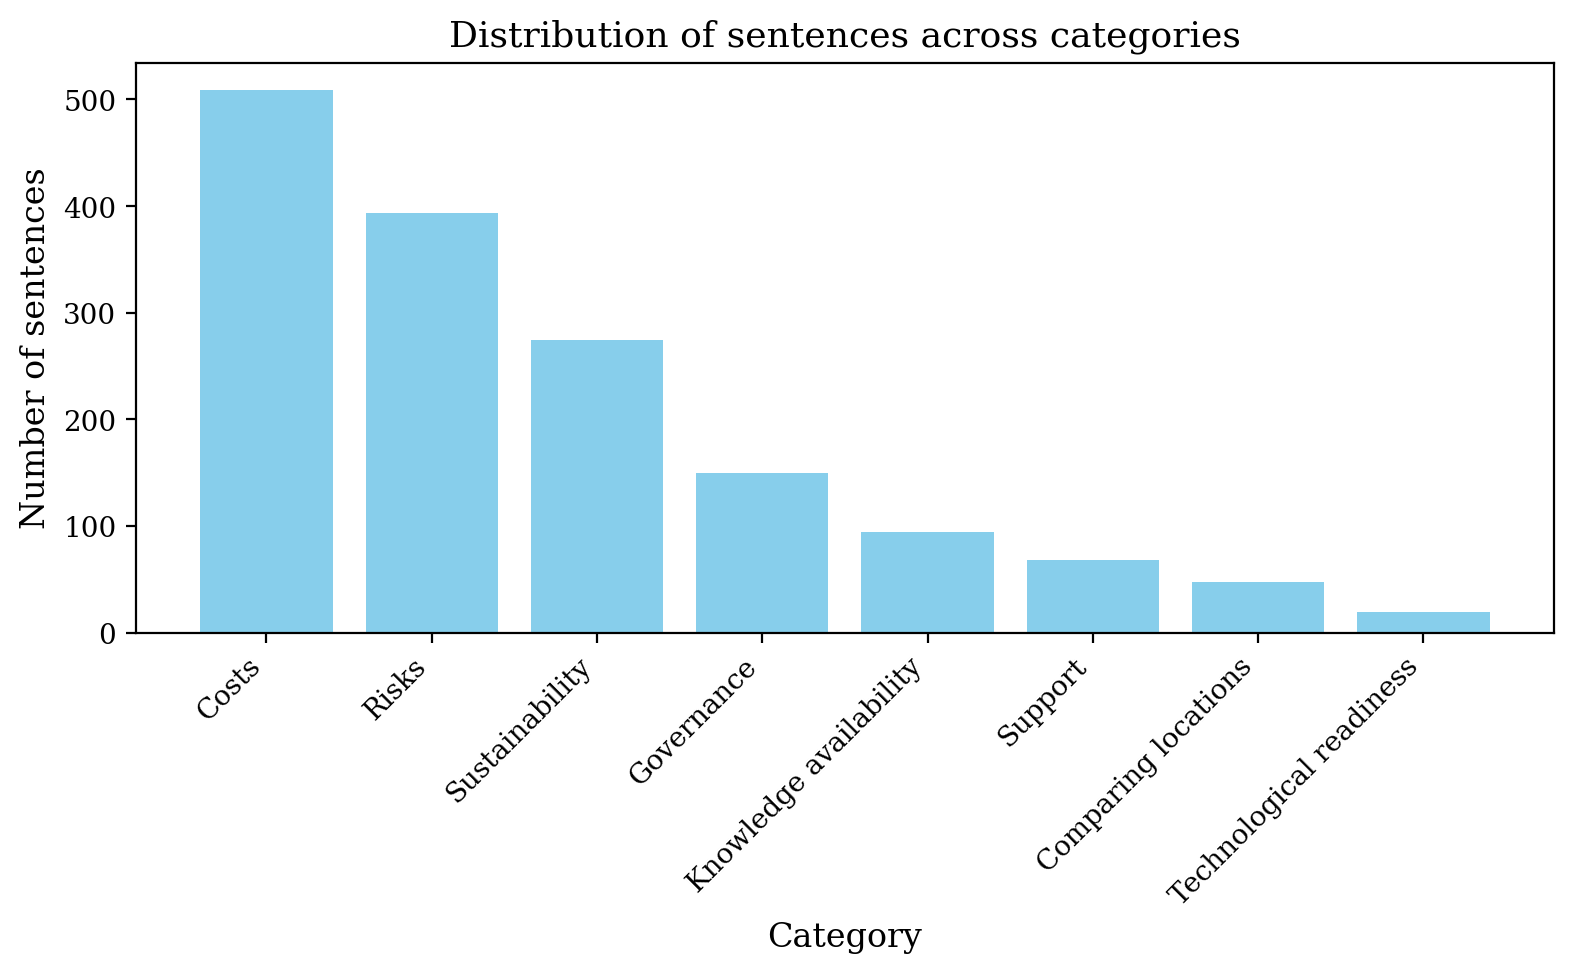

In [35]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import ast

sentences_csv = pd.read_csv("output/text/sentences_with_categories_short.csv")

cats = (
    sentences_csv["matched_categories_str"]
    .dropna()
    .str.split(";")
    .explode()
    .str.strip()
)

category_counts = cats.value_counts()
''
# Plot
fig, ax = plt.subplots(figsize=(8, 5), dpi=200)
ax.bar(category_counts.index, category_counts.values, color="skyblue")
ax.set_xlabel("Category")
ax.set_ylabel("Number of sentences")
ax.set_title("Distribution of sentences across categories")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [37]:
# print some general statistics 
total_sentences = len(sentences_csv)
sentences_with_category = sentences_csv["matched_categories_str"].notna().sum()
print(f"Total sentences: {total_sentences}")
print(f"Sentences with at least one category: {sentences_with_category} ({100 * sentences_with_category / total_sentences:.1f}%)")

Total sentences: 10713
Sentences with at least one category: 1463 (13.7%)


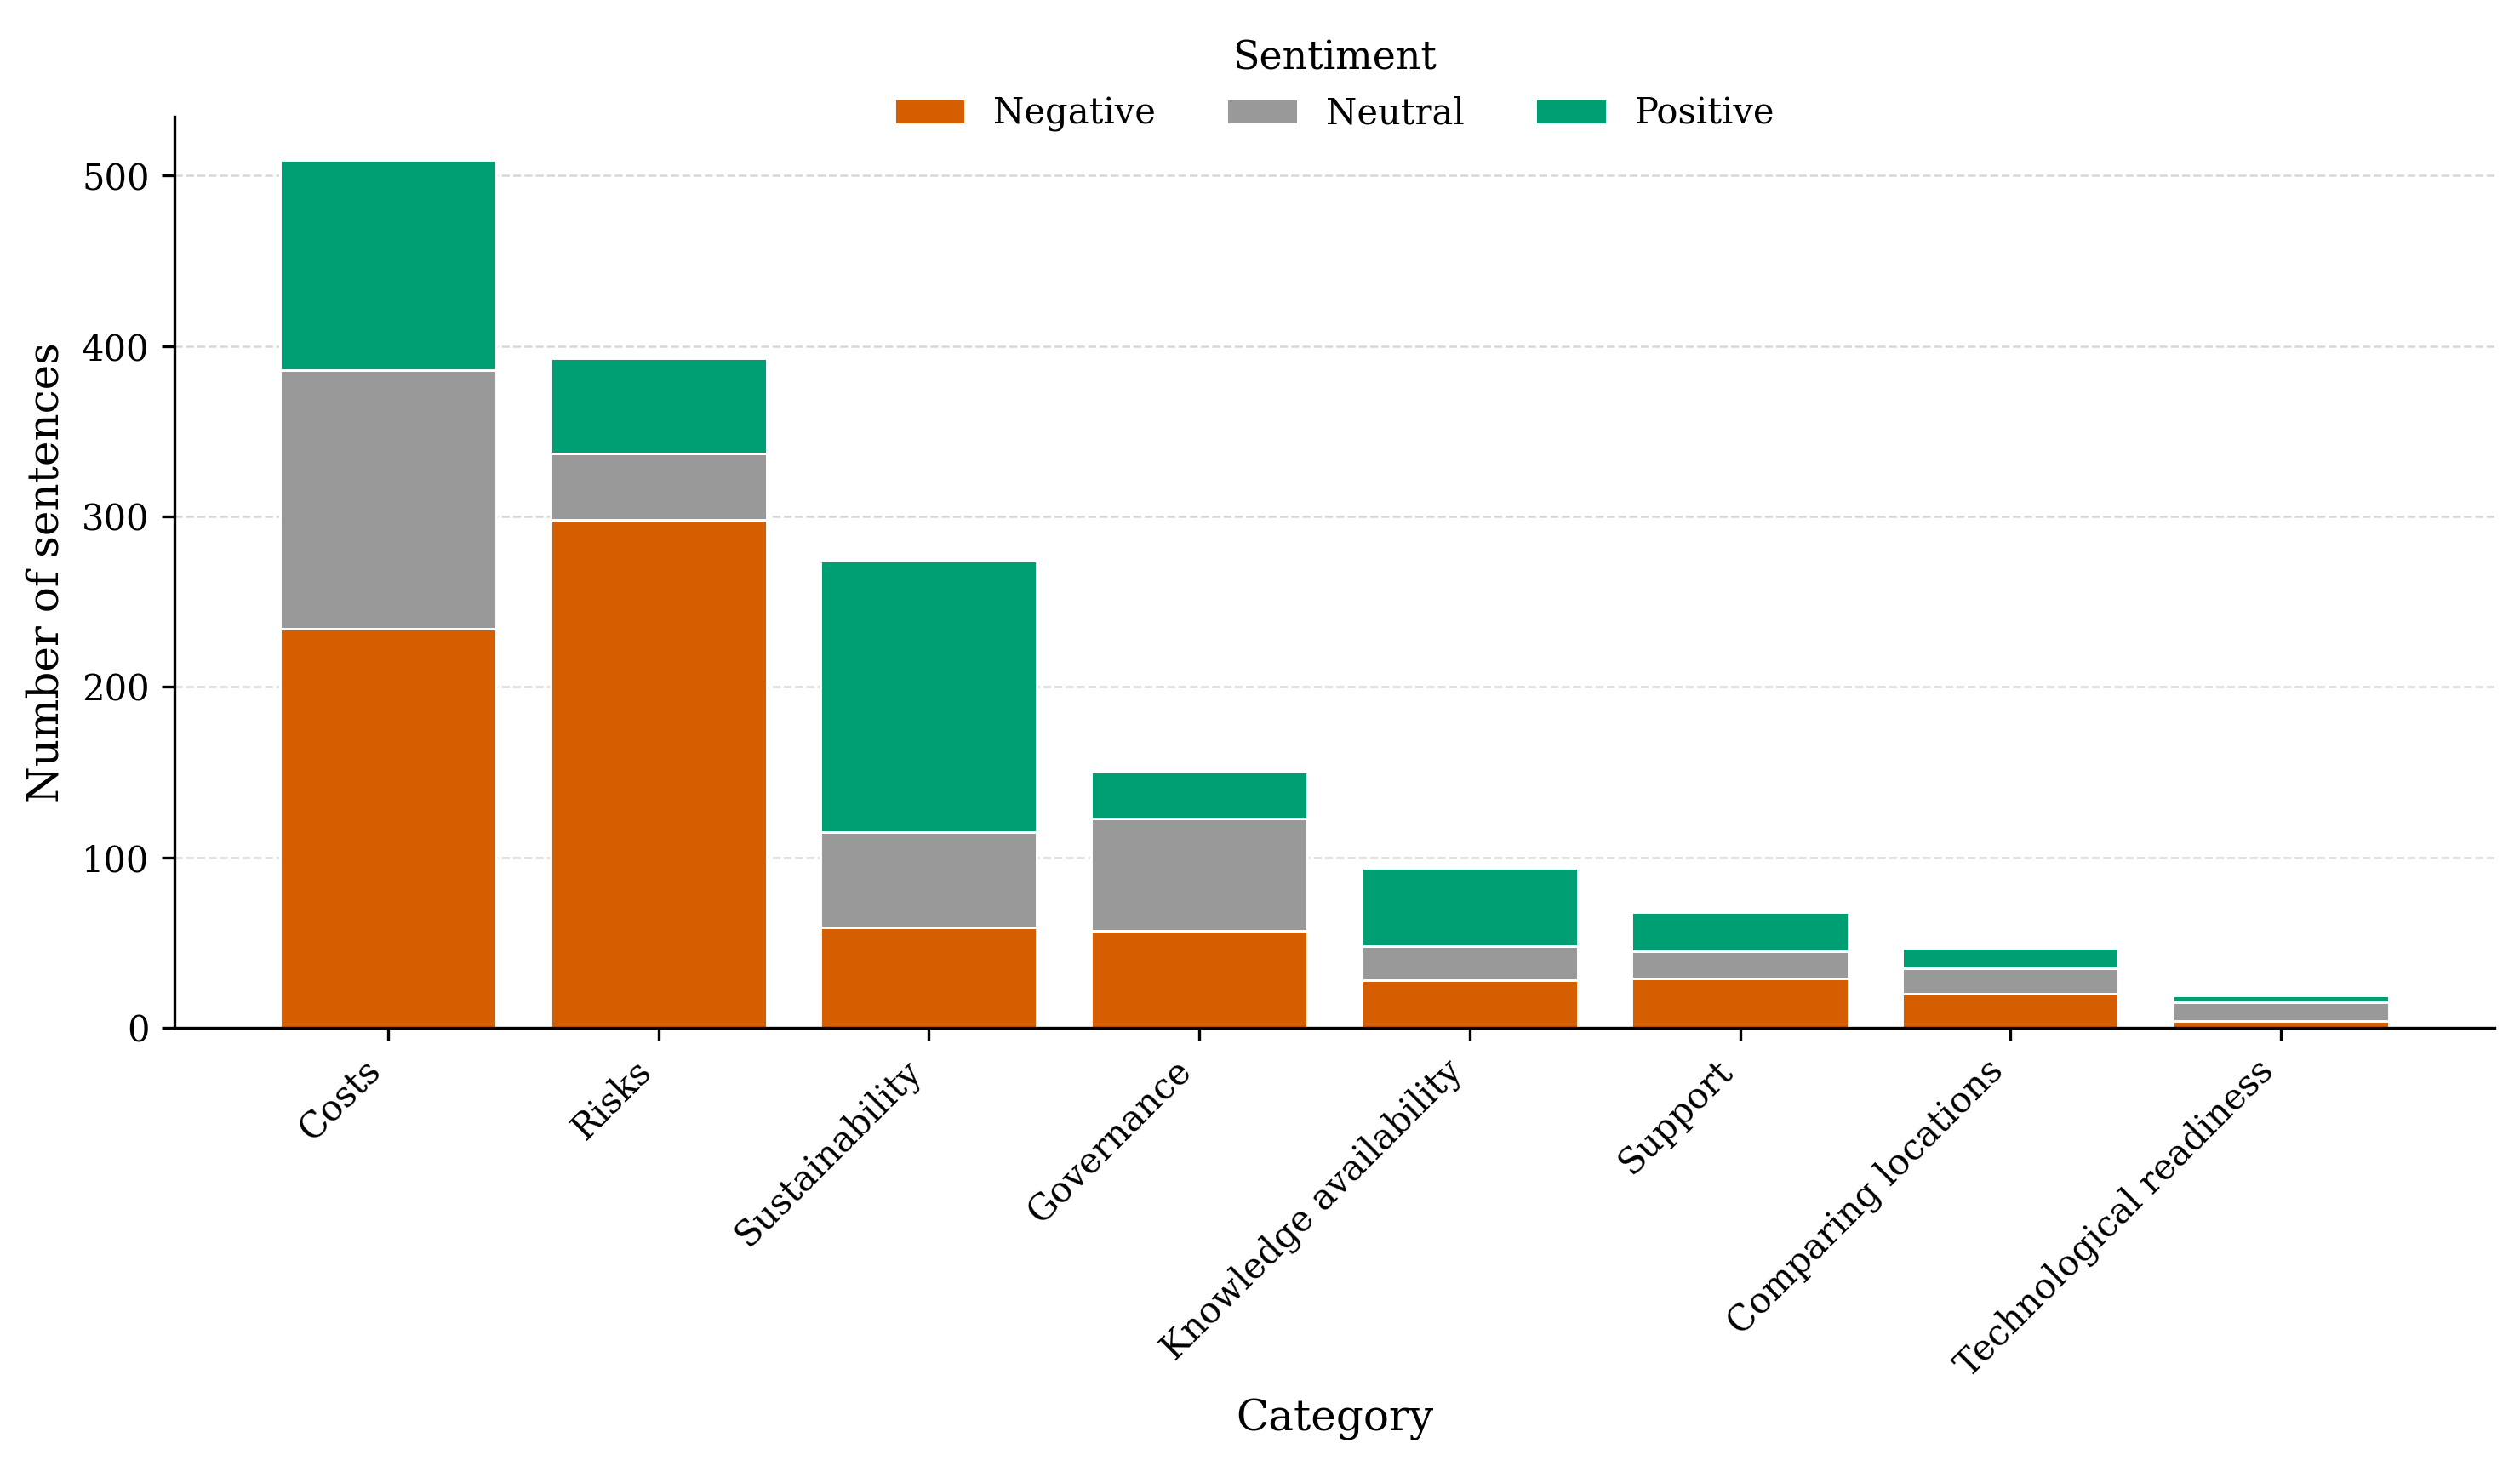

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Load data
# -----------------------------
sentences_csv = pd.read_csv("output/text/sentences_with_categories_short.csv")

# -----------------------------
# Settings: adapt these if needed
# -----------------------------
category_col = "matched_categories_str"
sentiment_col = "sentiment"   # expected values: positive / neutral / negative

# Optional: enforce sentiment order
sentiment_order = ["negative", "neutral", "positive"]

# Colorblind-friendly palette
sentiment_colors = {
    "negative": "#D55E00",
    "neutral":  "#999999",
    "positive": "#009E73",
}

# -----------------------------
# Prepare long-format dataframe
# -----------------------------
df = sentences_csv[[category_col, sentiment_col]].copy()

# Drop missing values in required columns
df = df.dropna(subset=[category_col, sentiment_col])

# Split semicolon-separated categories and explode
df["category"] = df[category_col].astype(str).str.split(";")
df = df.explode("category")
df["category"] = df["category"].str.strip()

# Clean empty categories if any
df = df[df["category"].notna() & (df["category"] != "")]

# Standardize sentiment strings
df[sentiment_col] = df[sentiment_col].astype(str).str.strip().str.lower()

# Keep only expected sentiments
df = df[df[sentiment_col].isin(sentiment_order)]

# -----------------------------
# Count sentiments per category
# -----------------------------
sentiment_counts = (
    df.groupby(["category", sentiment_col])
      .size()
      .unstack(fill_value=0)
)

# Ensure all sentiment columns exist and are ordered
for s in sentiment_order:
    if s not in sentiment_counts.columns:
        sentiment_counts[s] = 0
sentiment_counts = sentiment_counts[sentiment_order]

# Sort categories by total frequency (largest first)
sentiment_counts["total"] = sentiment_counts.sum(axis=1)
sentiment_counts = sentiment_counts.sort_values("total", ascending=False)
plot_data = sentiment_counts.drop(columns="total")

# -----------------------------
# Plot: stacked bar chart
# -----------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

bottom = pd.Series(0, index=plot_data.index)

for sentiment in sentiment_order:
    ax.bar(
        plot_data.index,
        plot_data[sentiment],
        bottom=bottom,
        label=sentiment.capitalize(),
        color=sentiment_colors[sentiment],
        edgecolor="white",
        linewidth=0.7,
    )
    bottom += plot_data[sentiment]

# Styling
ax.set_xlabel("Category")
ax.set_ylabel("Number of sentences")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.5)
ax.set_axisbelow(True)

plt.xticks(rotation=45, ha="right")

legend = ax.legend(
    title="Sentiment",
    frameon=False,
    ncol=3,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.12),
)

plt.tight_layout()
plt.show()

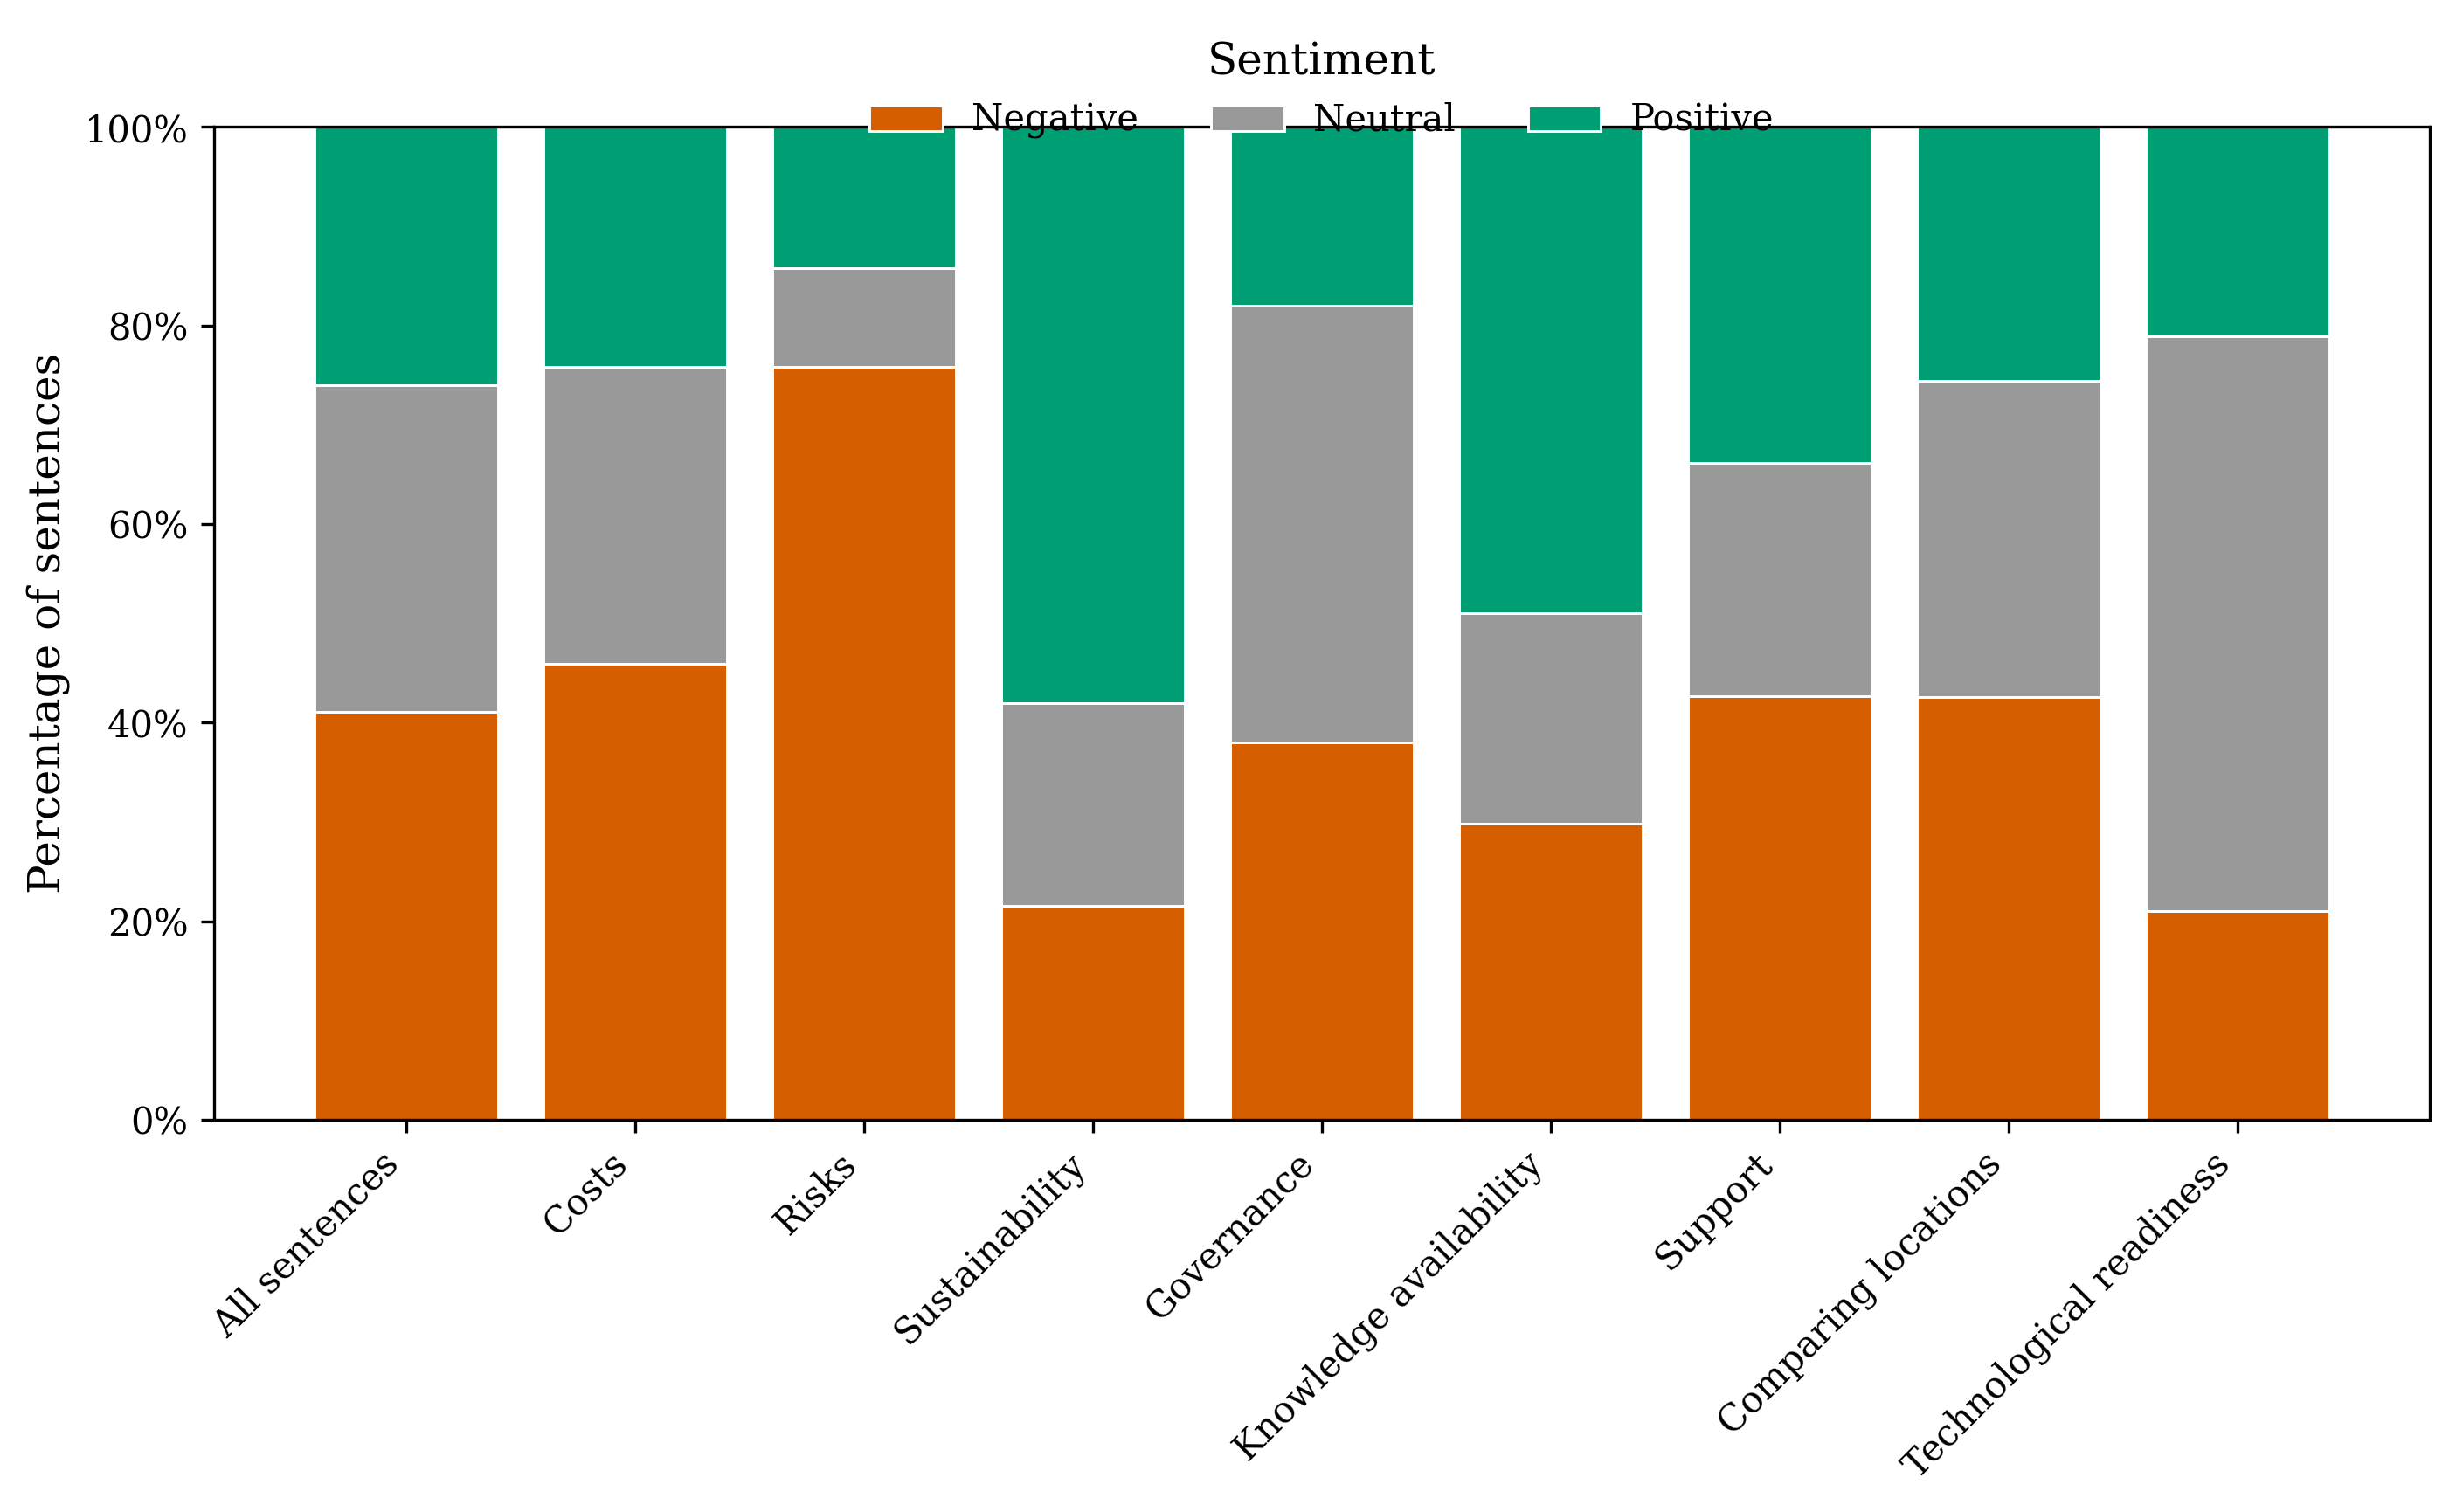

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt

os.chdir("/Users/Yannick/Documents/PhD/text_mining/geothermal")

# -----------------------------
# Load data
# -----------------------------
sentences_csv = pd.read_csv("output/text/sentences_with_categories_short.csv")

# -----------------------------
# Settings
# -----------------------------
category_col = "matched_categories_str"
sentiment_col = "sentiment"   # expected values: positive / neutral / negative

sentiment_order = ["negative", "neutral", "positive"]

# Colorblind-friendly palette
sentiment_colors = {
    "negative": "#D55E00",
    "neutral":  "#999999",
    "positive": "#009E73",
}

# -----------------------------
# Overall sentiment across ALL sentences
# -----------------------------
all_sentiments = sentences_csv[[sentiment_col]].copy()
all_sentiments = all_sentiments.dropna(subset=[sentiment_col])
all_sentiments[sentiment_col] = all_sentiments[sentiment_col].astype(str).str.strip().str.lower()
all_sentiments = all_sentiments[all_sentiments[sentiment_col].isin(sentiment_order)]

overall_counts = all_sentiments[sentiment_col].value_counts()
overall_counts = overall_counts.reindex(sentiment_order, fill_value=0)

overall_percent = (overall_counts / overall_counts.sum()) * 100

# -----------------------------
# Prepare long-format dataframe
# -----------------------------
df = sentences_csv[[category_col, sentiment_col]].copy()
df = df.dropna(subset=[category_col, sentiment_col])

df["category"] = df[category_col].astype(str).str.split(";")
df = df.explode("category")
df["category"] = df["category"].str.strip()

df = df[df["category"].notna() & (df["category"] != "")]
df[sentiment_col] = df[sentiment_col].astype(str).str.strip().str.lower()
df = df[df[sentiment_col].isin(sentiment_order)]

# -----------------------------
# Count sentiments per category
# -----------------------------
sentiment_counts = (
    df.groupby(["category", sentiment_col])
      .size()
      .unstack(fill_value=0)
)

for s in sentiment_order:
    if s not in sentiment_counts.columns:
        sentiment_counts[s] = 0
sentiment_counts = sentiment_counts[sentiment_order]

sentiment_counts["total"] = sentiment_counts.sum(axis=1)
sentiment_counts = sentiment_counts.sort_values("total", ascending=False)

plot_data = sentiment_counts.drop(columns="total").div(sentiment_counts["total"], axis=0) * 100

# Add overall bar
plot_data.loc["All sentences"] = overall_percent

# Optional: put overall bar first
plot_data = plot_data.loc[["All sentences"] + [idx for idx in plot_data.index if idx != "All sentences"]]

# -----------------------------
# Plot: 100% stacked bar chart
# -----------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "legend.title_fontsize": 12,
})

fig, ax = plt.subplots(figsize=(9.5, 6), dpi=300)

bottom = pd.Series(0, index=plot_data.index)

for sentiment in sentiment_order:
    ax.bar(
        plot_data.index,
        plot_data[sentiment],
        bottom=bottom,
        label=sentiment.capitalize(),
        color=sentiment_colors[sentiment],
        edgecolor="white",
        linewidth=0.7,
    )
    bottom += plot_data[sentiment]

# Styling
ax.set_ylabel("Percentage of sentences")
ax.set_ylim(0, 100)
ax.margins(y=0)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.8)
    spine.set_color("black")

ax.set_axisbelow(True)

plt.xticks(rotation=45, ha="right")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0f}%"))

legend = ax.legend(
    title="Sentiment",
    frameon=False,
    ncol=3,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.12),
)

plt.tight_layout()
plt.savefig(
    os.path.join("output/figures/poster/", "categories_sentiment_distribution.png"),
    bbox_inches="tight"
)
plt.show()

In [ ]:
# import province_counts from previous code if not already in memory prov_counts.to_csv(os.path.join(OUT_DIR, "provincie_counts.csv"), index=False)
if 'prov_counts' not in locals():
    prov_counts = pd.read_csv("output/figures/sentiment_analysis_geom/tables/provincie_sentiment_table_with_country.csv")

prov_counts.to_csv(os.path.join(OUT_DIR, "provincie_counts.csv"), index=False)



In [ ]:
sentences = pd.read_csv("output/text/sentences_with_categories_long.csv")
print(f"Total sentences in long-format CSV: {len(sentences)}")

sentences_unique = sentences.drop_duplicates(subset=['sentence_text'])
print(f"Unique sentences after dropping duplicates: {len(sentences_unique)}")

annotation_df = sentences_unique.sample(n=1000, random_state=42)


#Add sentence ID column for annotation
annotation_df["sentence_id"] = range(1, len(annotation_df) + 1)

# Save to CSV for annotation
ANNOTATION_PATH = "annotation/sentences_for_annotation.csv"
annotation_df.to_csv(ANNOTATION_PATH, index=False)


Total sentences in long-format CSV: 10713
Unique sentences after dropping duplicates: 10713


In [54]:
annotation_df = pd.read_csv("annotation/sentences_for_annotation.csv")

print(annotation_df.columns)

Index(['sentence_uid', 'row_id', 'sentence_id', 'sentence_text', 'aspect',
       'sentiment', 'sentiment_norm', 'confidence', 'position', 'llm_location',
       'llm_granularity', 'llm_location.1', 'llm_granularity.1', 'source_file',
       'source_path', 'newspaper', 'date', 'body', 'source', 'region_name',
       '_gran', '_loc_first', '_loc_norm', '_join_key', 'geo_level',
       'geo_name_matched', 'geo_source', 'geo_match_type', 'geo_lat',
       'geo_lon', 'geom_point_wkt', 'geom_poly_wkt', 'municipality_name',
       'province_name', 'geometry'],
      dtype='object')


In [68]:
import pandas as pd

aggregated_framework = pd.read_csv("output/text/sentences_with_categories_admin.csv")

category_col = "matched_categories_str"
province_col = "province_name"

# count sentences per province/category
category_counts = (
    aggregated_framework.groupby([province_col, category_col])
    .size()
    .reset_index(name="count")
)

# rank categories within each province
top_categories = (
    category_counts
    .sort_values([province_col, "count"], ascending=[True, False])
    .groupby(province_col)
    .head(3)
    .copy()
)

# label them as 1st / 2nd / 3rd
top_categories["rank"] = top_categories.groupby(province_col).cumcount() + 1

# reshape so each province is a column and rows are 1st, 2nd, 3rd
result = (
    top_categories.pivot(index="rank", columns=province_col, values=category_col)
    .rename(index={1: "first", 2: "second", 3: "third"})
)

print(result)

province_name                  Drenthe Flevoland     Fryslân      Gelderland  \
rank                                                                           
first                            Risks     Costs       Costs  Sustainability   
second                           Costs       NaN  Governance           Costs   
third          Technological readiness       NaN       Risks      Governance   

province_name   Groningen         Limburg Noord-Brabant   Noord-Holland  \
rank                                                                      
first               Costs           Risks         Costs           Costs   
second              Risks           Costs         Risks  Sustainability   
third          Governance  Sustainability    Governance      Governance   

province_name  Overijssel                 Utrecht    Zuid-Holland  
rank                                                               
first               Costs          Sustainability           Costs  
second             